# 🎓 Smart Campus Recruitment System
## Model 2 — Resume Scorer (ATS Simulator)

### Datasets (add all via Kaggle → + Add Data):
| # | Dataset | Kaggle slug | Role |
|---|---------|-------------|------|
| 1 | **LinkedIn Job Postings 2023-2024** | `arshkon/linkedin-job-postings` | Primary JD source — 124k real postings with descriptions, skills, titles |
| 2 | **Resume Entities for NER** | `dataturks/resume-entities-for-ner` | Resume text source — 220 annotated resumes used to simulate Model 1 output |

### Model 1 output schema (exact fields this model consumes):
```json
{
  "name": "string",
  "email": "string",
  "phone": "string",
  "location": ["string"],
  "links": ["string"],
  "skills": ["string"],
  "designations": ["string"],
  "companies": ["string"],
  "degree": ["string"],
  "colleges": ["string"],
  "graduation_year": ["string"],
  "years_experience": "string",
  "certifications": ["string"]
}
```

### What Model 2 outputs:
```json
{
  "ats_score": 78.4,
  "section_scores": {
    "skills": 82.1, "experience": 75.0,
    "education": 80.0, "semantic": 76.3
  },
  "matched_keywords": ["Python", "Machine Learning"],
  "missing_keywords": ["Docker", "Kubernetes", "AWS"],
  "suggestions": ["Add Docker to your skills section", ...],
  "job_title": "Data Scientist",
  "company": "Google"
}
```

### Pipeline:
1. Load & explore LinkedIn JD dataset (EDA)
2. Load & process resume texts (simulate Model 1 output)
3. Feature engineering — 8 scoring dimensions
4. Normalization & PCA
5. Construct pseudo-labels (TF-IDF + category matching)
6. Train / Val / Test split
7. XGBoost scorer + Sentence-BERT semantic layer
8. Evaluation (MAE, RMSE, Spearman correlation)
9. Suggestion generator
10. Production scorer function (takes Model 1 JSON → full output)


## 📦 Cell 1 — Install & import

In [2]:
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('sentence-transformers')
pip('xgboost')
pip('lightgbm')
pip('shap')
pip('wordcloud')
pip('umap-learn')
pip('fuzzywuzzy')
pip('python-Levenshtein')

import os, re, json, warnings, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud
from fuzzywuzzy import fuzz
warnings.filterwarnings('ignore')

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
import xgboost as xgb
import lightgbm as lgb
import shap
import umap

# ── NLP / Embeddings ──────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer, util

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
PALETTE = sns.color_palette('tab20', 20)
print('All imports done.')

All imports done.


## 📂 Cell 2 — Load datasets

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset 1: LinkedIn Job Postings (arshkon/linkedin-job-postings)
# Key files inside this dataset:
#   postings.csv       — main job records (job_id, title, description, ...)
#   mappings/skills.csv — job_id → skill_abr mapping
#   mappings/job_skills.csv — join table
# ─────────────────────────────────────────────────────────────────────────────

JD_PATH        = '/content/drive/MyDrive/Dataset/archive/postings.csv'
SKILLS_MAP     = '/content/drive/MyDrive/Dataset/archive/mappings/skills.csv'
JOB_SKILLS_MAP = '/content/drive/MyDrive/Dataset/archive/jobs/job_skills.csv'

# Dataset 2: NER resume texts
NER_PATH = '/content/drive/MyDrive/Dataset/Entity Recognition in Resumes.json'

# ── Load JD postings ──────────────────────────────────────────────────────────
df_jd = pd.read_csv(JD_PATH, low_memory=False)
print(f'JD postings shape      : {df_jd.shape}')
print(f'JD columns             : {list(df_jd.columns)}')

# ── Load skills mapping ───────────────────────────────────────────────────────
try:
    df_skills_map = pd.read_csv(SKILLS_MAP)
    df_job_skills = pd.read_csv(JOB_SKILLS_MAP)
    print(f'Skills map shape       : {df_skills_map.shape}')
    print(f'Job-skills shape       : {df_job_skills.shape}')
    HAS_SKILLS_MAP = True
except:
    print('Skills map files not found — will extract skills from description text.')
    HAS_SKILLS_MAP = False

# ── Load resume texts ─────────────────────────────────────────────────────────
raw_records = []
with open(NER_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw_records.append(json.loads(line))
print(f'\nResume records loaded  : {len(raw_records)}')
print('\nFirst few JD columns preview:')
print(df_jd[['title', 'description', 'work_type', 'formatted_experience_level']].head(3))

JD postings shape      : (123849, 31)
JD columns             : ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']
Skills map shape       : (35, 2)
Job-skills shape       : (213768, 2)

Resume records loaded  : 220

First few JD columns preview:
                               title  \
0              Marketing Coordinator   
1  Mental Health Therapist/Counselor   
2        Assitant Restaurant Manager   

                                         description  work_type  \
0  Job descriptionA leading real estate firm in N...  FULL_TIME   
1  At Aspen Therapy and Wellness

## 🔬 Cell 3 — JD Data Cleaning & Preprocessing

In [4]:
# ── Keep only the columns we need & clean ─────────────────────────────────────
KEEP_COLS = ['job_id', 'title', 'description', 'company_name',
             'formatted_experience_level', 'work_type', 'applies',
             'remote_allowed', 'min_salary', 'max_salary']
KEEP_COLS = [c for c in KEEP_COLS if c in df_jd.columns]
df_jd = df_jd[KEEP_COLS].copy()

# ── Drop rows with no description (unusable for scoring) ─────────────────────
df_jd = df_jd.dropna(subset=['description']).reset_index(drop=True)
print(f'After dropping null descriptions: {len(df_jd)} rows')

# ── Clean description text ────────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)  # strip URLs
    text = re.sub(r'[\r\n\t]+', ' ', text)        # flatten whitespace
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)    # strip non-ASCII
    text = re.sub(r'\s{2,}', ' ', text).strip()   # collapse spaces
    return text

df_jd['description_clean'] = df_jd['description'].apply(clean_text)
df_jd['title_clean']       = df_jd['title'].apply(clean_text)

# ── Derive broad job category from title ─────────────────────────────────────
CATEGORY_KEYWORDS = {
    'Data Science'         : ['data scientist', 'ml engineer', 'machine learning', 'ai engineer'],
    'Data Engineering'     : ['data engineer', 'etl', 'pipeline', 'spark', 'databricks'],
    'Software Engineering' : ['software engineer', 'backend', 'frontend', 'full stack', 'developer'],
    'Data Analytics'       : ['data analyst', 'business analyst', 'analytics', 'bi developer'],
    'DevOps/Cloud'         : ['devops', 'cloud', 'infrastructure', 'sre', 'platform engineer'],
    'Product Management'   : ['product manager', 'product owner', 'program manager'],
    'Cybersecurity'        : ['security', 'penetration', 'soc analyst', 'infosec'],
    'Other'                : [],
}

def assign_category(title):
    t = str(title).lower()
    for cat, kws in CATEGORY_KEYWORDS.items():
        if any(kw in t for kw in kws):
            return cat
    return 'Other'

df_jd['category'] = df_jd['title_clean'].apply(assign_category)

# ── Experience level normalisation ────────────────────────────────────────────
EXP_MAP = {
    'Internship': 0, 'Entry level': 1, 'Associate': 2,
    'Mid-Senior level': 4, 'Director': 8, 'Executive': 12
}
df_jd['exp_years_required'] = df_jd['formatted_experience_level'].map(EXP_MAP).fillna(2)

print(df_jd[['title_clean', 'category', 'exp_years_required']].head(5))
print(f"\nCategory distribution:\n{df_jd['category'].value_counts()}")

After dropping null descriptions: 123842 rows
                                         title_clean category  \
0                              Marketing Coordinator    Other   
1                  Mental Health Therapist/Counselor    Other   
2                        Assitant Restaurant Manager    Other   
3  Senior Elder Law / Trusts and Estates Associat...    Other   
4                                 Service Technician    Other   

   exp_years_required  
0                 2.0  
1                 2.0  
2                 2.0  
3                 2.0  
4                 2.0  

Category distribution:
category
Other                   113628
Software Engineering      4116
Cybersecurity             1508
Data Analytics            1302
Product Management        1257
DevOps/Cloud              1068
Data Engineering           537
Data Science               426
Name: count, dtype: int64


In [5]:
# ── Extract required skills from JD descriptions (TF-IDF + keyword list) ──────

# Comprehensive tech skill vocabulary used for keyword extraction
TECH_SKILLS_VOCAB = [
    'python','java','javascript','typescript','c++','c#','r','scala','go','rust','kotlin','swift',
    'sql','nosql','postgresql','mysql','mongodb','redis','cassandra','elasticsearch','dynamodb',
    'tensorflow','pytorch','keras','scikit-learn','xgboost','lightgbm','spark','hadoop','kafka',
    'machine learning','deep learning','nlp','computer vision','reinforcement learning','llm',
    'docker','kubernetes','aws','azure','gcp','terraform','ansible','jenkins','ci/cd','git',
    'react','angular','vue','node.js','django','flask','fastapi','spring boot','rest api','graphql',
    'tableau','power bi','looker','airflow','dbt','mlflow','kubeflow','huggingface',
    'data structures','algorithms','system design','microservices','agile','scrum',
    'excel','pandas','numpy','matplotlib','seaborn','pyspark','databricks','snowflake','redshift',
    'communication','leadership','problem solving','teamwork','analytical',
    'bert','gpt','transformer','langchain','openai','rag','vector database','pinecone','faiss'
]

def extract_skills_from_text(text):
    """Extract known tech skills mentioned in a JD description."""
    text_lower = text.lower()
    found = []
    for skill in TECH_SKILLS_VOCAB:
        # Use word boundary matching
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found.append(skill)
    return found

print('Extracting required skills from JD descriptions (this may take ~2 mins)...')
df_jd['required_skills'] = df_jd['description_clean'].apply(extract_skills_from_text)
df_jd['n_required_skills'] = df_jd['required_skills'].apply(len)

# If official skills map is available, enrich with it
if HAS_SKILLS_MAP:
    skill_lookup = dict(zip(df_skills_map.iloc[:, 0], df_skills_map.iloc[:, 1]))
    job_skill_dict = df_job_skills.groupby('job_id')['skill_abr'].apply(list).to_dict()
    def enrich_skills(row):
        official = [skill_lookup.get(s, s) for s in job_skill_dict.get(row['job_id'], [])]
        return list(set(row['required_skills'] + [s.lower() for s in official]))
    df_jd['required_skills'] = df_jd.apply(enrich_skills, axis=1)
    df_jd['n_required_skills'] = df_jd['required_skills'].apply(len)
    print('Skills enriched from official mappings.')

# Sample JDs with good skill coverage
df_jd_good = df_jd[df_jd['n_required_skills'] >= 3].reset_index(drop=True)
print(f'\nJDs with ≥3 required skills: {len(df_jd_good):,}')
print(f'Avg skills per JD: {df_jd_good["n_required_skills"].mean():.1f}')

Extracting required skills from JD descriptions (this may take ~2 mins)...
Skills enriched from official mappings.

JDs with ≥3 required skills: 76,458
Avg skills per JD: 4.4


## 📊 Cell 4 — Exploratory Data Analysis (EDA)

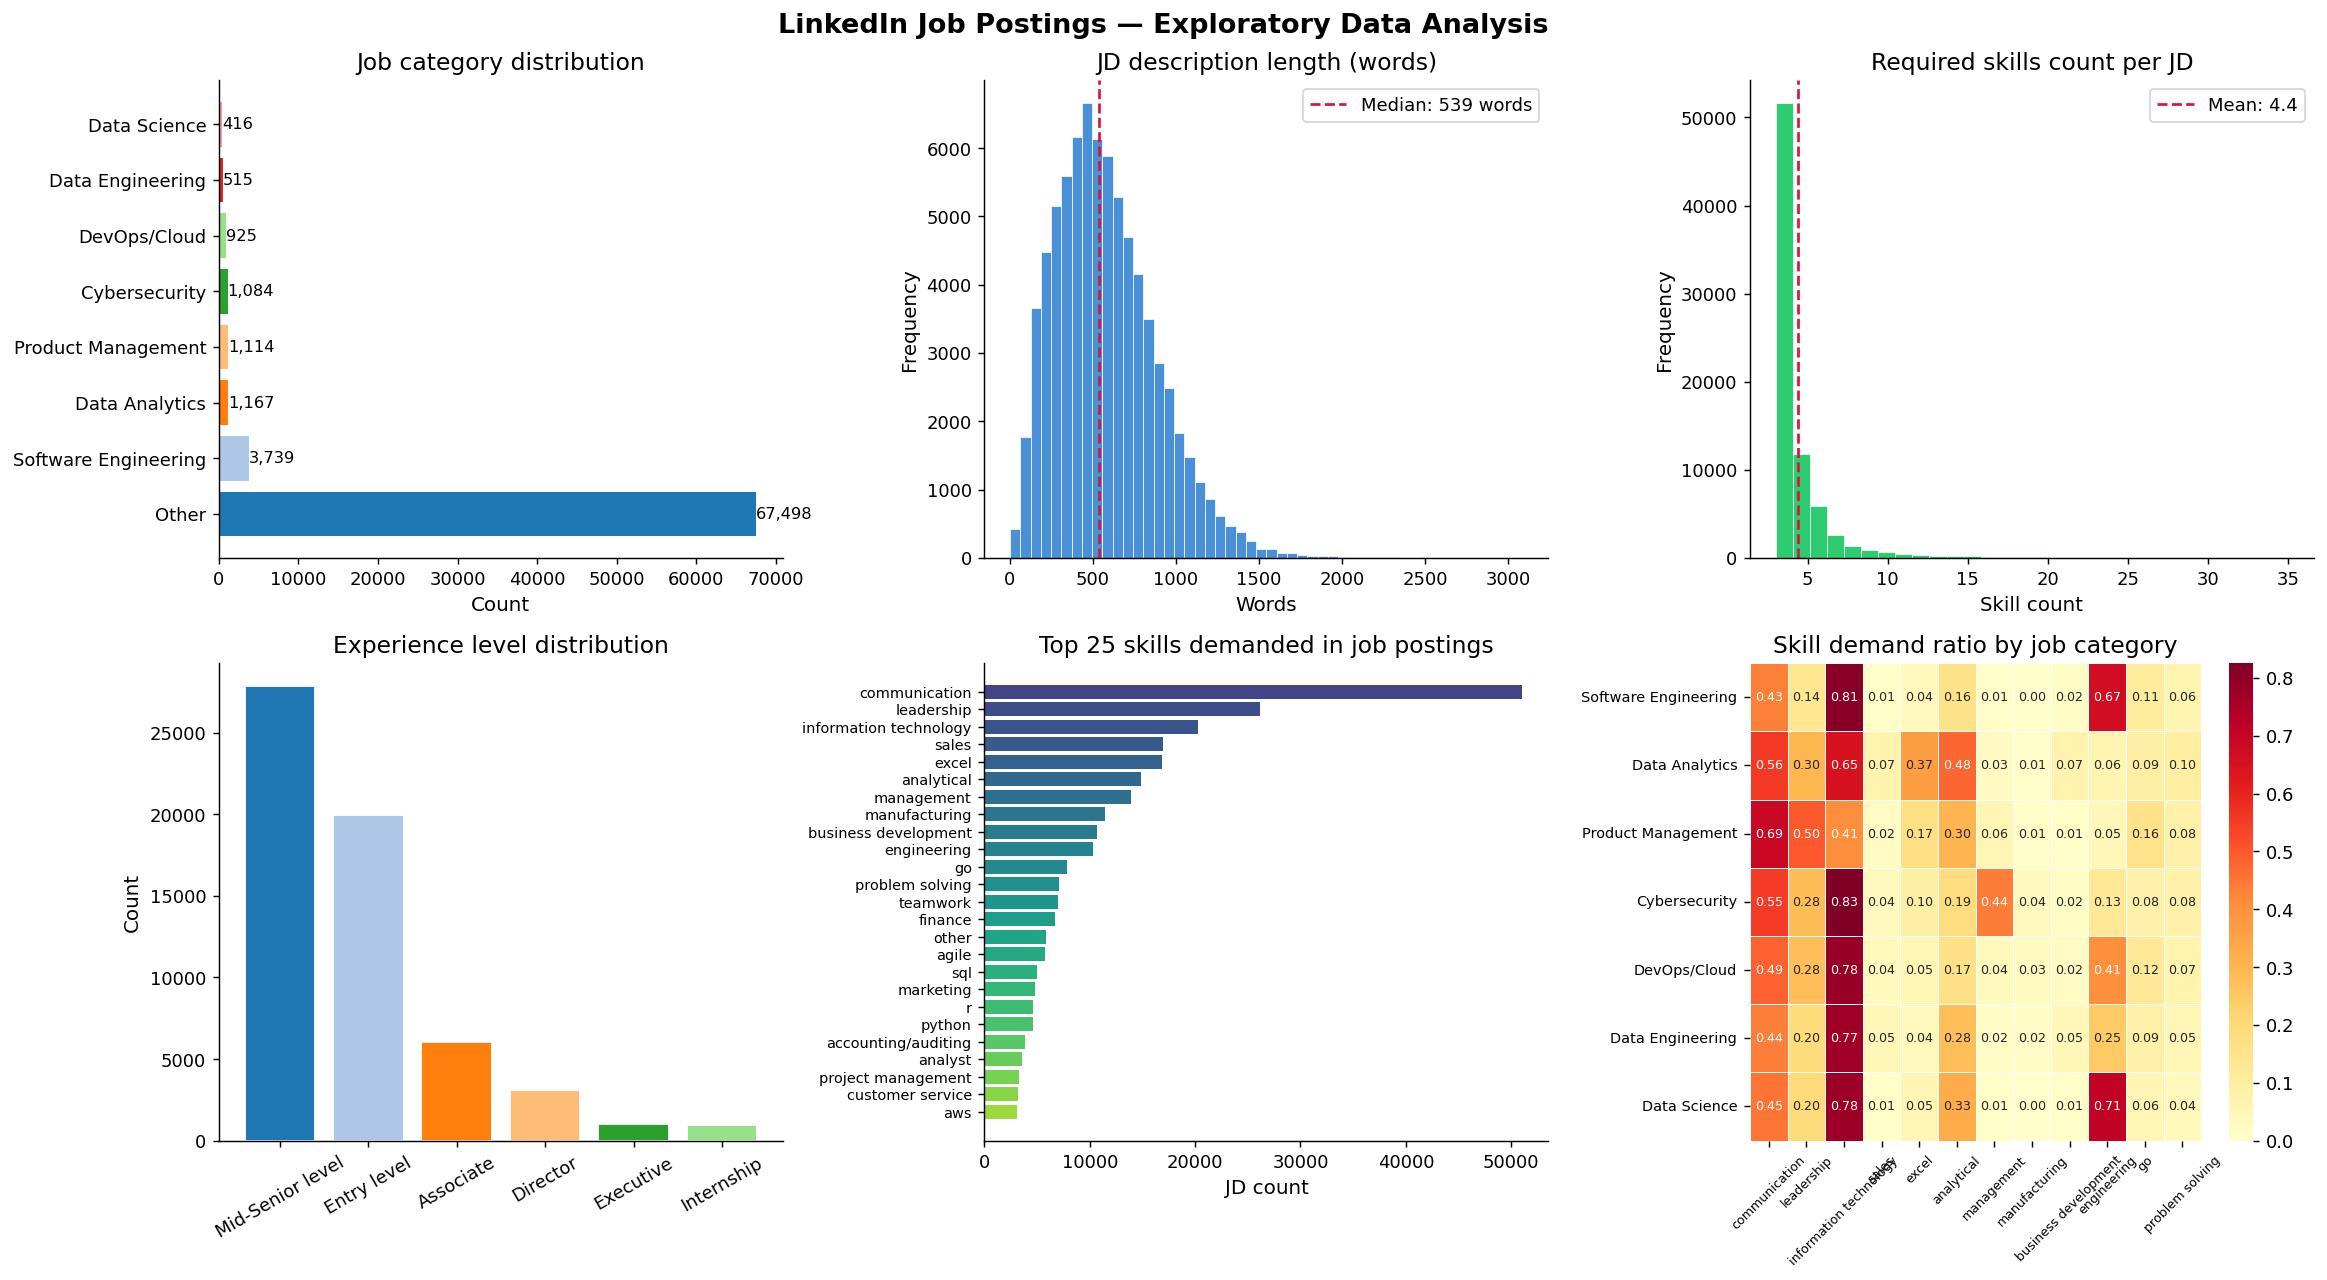

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LinkedIn Job Postings — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# ── 1. Job category distribution ──────────────────────────────────────────────
ax = axes[0, 0]
cat_vc = df_jd_good['category'].value_counts()
bars = ax.barh(cat_vc.index, cat_vc.values, color=PALETTE[:len(cat_vc)])
ax.set_title('Job category distribution')
ax.set_xlabel('Count')
for bar, v in zip(bars, cat_vc.values):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)

# ── 2. JD description length distribution ────────────────────────────────────
ax = axes[0, 1]
desc_lens = df_jd_good['description_clean'].str.split().str.len()
ax.hist(desc_lens, bins=50, color='#4A90D9', edgecolor='white', linewidth=0.4)
ax.axvline(desc_lens.median(), color='crimson', linestyle='--',
           label=f'Median: {int(desc_lens.median())} words')
ax.set_title('JD description length (words)')
ax.set_xlabel('Words'); ax.set_ylabel('Frequency')
ax.legend()

# ── 3. Required skills count per JD ──────────────────────────────────────────
ax = axes[0, 2]
ax.hist(df_jd_good['n_required_skills'], bins=30, color='#2ECC71', edgecolor='white', linewidth=0.4)
ax.axvline(df_jd_good['n_required_skills'].mean(), color='crimson', linestyle='--',
           label=f'Mean: {df_jd_good["n_required_skills"].mean():.1f}')
ax.set_title('Required skills count per JD')
ax.set_xlabel('Skill count'); ax.set_ylabel('Frequency')
ax.legend()

# ── 4. Experience level distribution ─────────────────────────────────────────
ax = axes[1, 0]
if 'formatted_experience_level' in df_jd_good.columns:
    exp_vc = df_jd_good['formatted_experience_level'].value_counts().dropna()
    ax.bar(exp_vc.index, exp_vc.values, color=PALETTE[:len(exp_vc)], edgecolor='white')
    ax.set_title('Experience level distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

# ── 5. Top 25 most demanded skills ────────────────────────────────────────────
ax = axes[1, 1]
all_skills = [s for skills in df_jd_good['required_skills'] for s in skills]
top_skills = Counter(all_skills).most_common(25)
sk_names, sk_counts = zip(*top_skills)
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(sk_names)))
ax.barh(sk_names[::-1], sk_counts[::-1], color=colors[::-1])
ax.set_title('Top 25 skills demanded in job postings')
ax.set_xlabel('JD count')
ax.tick_params(axis='y', labelsize=8)

# ── 6. Skill demand heatmap by category ───────────────────────────────────────
ax = axes[1, 2]
TOP_SKILLS_FOR_HEAT = [s for s, _ in Counter(all_skills).most_common(12)]
cats_for_heat = [c for c in cat_vc.index if c != 'Other']
heat_data = []
for cat in cats_for_heat:
    sub = df_jd_good[df_jd_good['category'] == cat]
    cat_skills = [s for skills in sub['required_skills'] for s in skills]
    cat_total  = len(sub) + 1
    row = [cat_skills.count(sk) / cat_total for sk in TOP_SKILLS_FOR_HEAT]
    heat_data.append(row)
heat_df = pd.DataFrame(heat_data, index=cats_for_heat, columns=TOP_SKILLS_FOR_HEAT)
sns.heatmap(heat_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size': 7})
ax.set_title('Skill demand ratio by job category')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig('eda_jd_overview.png', bbox_inches='tight')
plt.show()

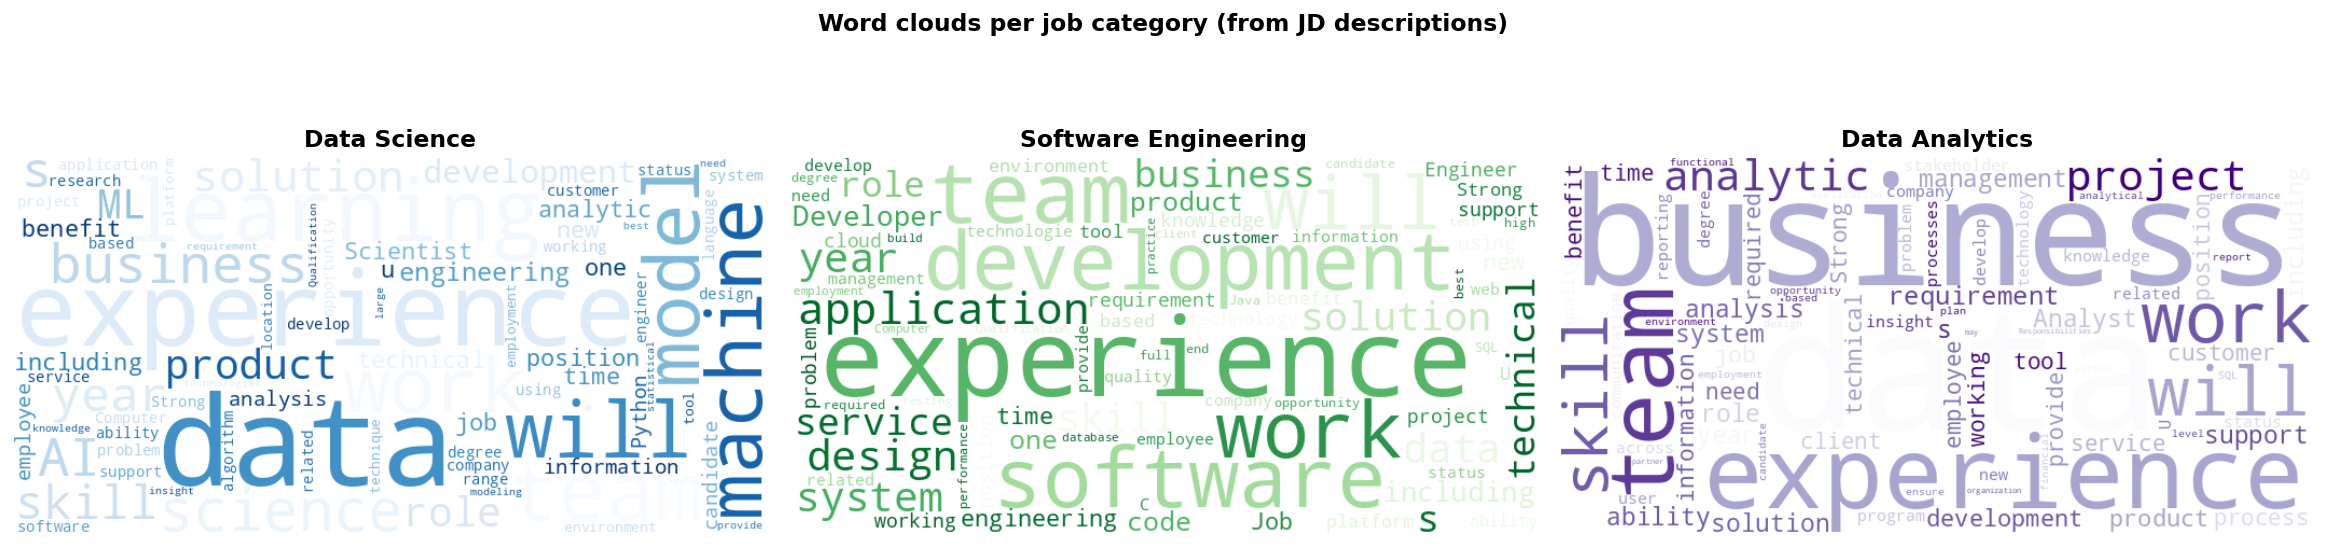

In [7]:
# ── Word cloud — JD descriptions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word clouds per job category (from JD descriptions)', fontsize=13, fontweight='bold')

WC_CATS = ['Data Science', 'Software Engineering', 'Data Analytics']
WC_MAPS = ['Blues', 'Greens', 'Purples']
for ax, cat, cmap in zip(axes, WC_CATS, WC_MAPS):
    text = ' '.join(df_jd_good[df_jd_good['category'] == cat]['description_clean'].dropna())
    wc = WordCloud(
        width=700, height=350, background_color='white',
        colormap=cmap, max_words=80, collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_jd.png', bbox_inches='tight')
plt.show()

## 🧩 Cell 5 — Simulate Model 1 output for all resumes

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# We simulate Model 1's parse_resume() output from the NER dataset's
# raw text + annotations. In production, you simply call parse_resume()
# from resume_parser.py and pass the resulting dict directly to score_resume().
# ─────────────────────────────────────────────────────────────────────────────

LABEL_NORM = {
    'Name':'NAME','Email Address':'EMAIL','Phone Number':'PHONE',
    'Skills':'SKILLS','Degree':'DEGREE','College Name':'COLLEGE',
    'Companies worked at':'COMPANY','Designation':'DESIGNATION',
    'Location':'LOCATION','Years of Experience':'EXPERIENCE',
    'Graduation Year':'GRAD_YEAR','Certification':'CERTIFICATION',
    'Links':'LINKS'
}

def simulated_parse_resume(record):
    """
    Converts a raw NER record into the same JSON schema that
    resume_parser.py's parse_resume() outputs from Model 1.
    """
    text = record.get('content', '')
    annotations = record.get('annotation') or []
    entities = defaultdict(list)

    for ann in annotations:
        lbl_raw = ann.get('label', [''])
        if isinstance(lbl_raw, list):
            lbl_raw = lbl_raw[0] if lbl_raw else ''
        label = LABEL_NORM.get(lbl_raw, lbl_raw.upper())
        for pt in ann.get('points', []):
            val = pt.get('text', '').strip()
            if val:
                entities[label].append(val)

    def dedup(lst):
        seen, out = set(), []
        for x in lst:
            xn = x.lower()
            if xn not in seen:
                seen.add(xn); out.append(x)
        return out

    # Flatten skills: split comma/bullet delimited spans
    raw_skills = entities.get('SKILLS', [])
    flat_skills = []
    for s in raw_skills:
        for token in re.split(r'[,\n•·|/]', s):
            t = token.strip()
            if 2 < len(t) < 50:
                flat_skills.append(t.lower())
    flat_skills = dedup(flat_skills)

    # Extract years of experience as integer
    exp_raw = ' '.join(entities.get('EXPERIENCE', [])) + ' ' + text
    exp_match = re.search(r'(\d+)\+?\s*(?:years?|yrs?)', exp_raw, re.IGNORECASE)
    years_exp = int(exp_match.group(1)) if exp_match else 0

    return {
        'raw_text'        : text,           # kept for semantic scoring
        'name'            : entities.get('NAME', [''])[0],
        'email'           : entities.get('EMAIL', [''])[0],
        'phone'           : entities.get('PHONE', [''])[0],
        'location'        : dedup(entities.get('LOCATION', [])),
        'links'           : dedup(entities.get('LINKS', [])),
        'skills'          : flat_skills,
        'designations'    : dedup(entities.get('DESIGNATION', [])),
        'companies'       : dedup(entities.get('COMPANY', [])),
        'degree'          : dedup(entities.get('DEGREE', [])),
        'colleges'        : dedup(entities.get('COLLEGE', [])),
        'graduation_year' : dedup(entities.get('GRAD_YEAR', [])),
        'years_experience': years_exp,
        'certifications'  : dedup(entities.get('CERTIFICATION', [])),
    }

parsed_resumes = [simulated_parse_resume(r) for r in raw_records]
print(f'Parsed {len(parsed_resumes)} resumes.')

# Quick stats
avg_skills = np.mean([len(r['skills']) for r in parsed_resumes])
pct_with_exp = np.mean([r['years_experience'] > 0 for r in parsed_resumes]) * 100
print(f'Avg skills per resume    : {avg_skills:.1f}')
print(f'Resumes with exp years   : {pct_with_exp:.0f}%')
print('\nSample parsed resume:')
sample_r = parsed_resumes[0]
print(json.dumps({k: v for k, v in sample_r.items() if k != 'raw_text'}, indent=2)[:600])

Parsed 220 resumes.
Avg skills per resume    : 11.8
Resumes with exp years   : 70%

Sample parsed resume:
{
  "name": "Abhishek Jha",
  "email": "Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a",
  "phone": "",
  "location": [
    "Bengaluru"
  ],
  "links": [],
  "skills": [
    "programming language: c",
    "c++",
    "java",
    "oracle peoplesoft",
    "internet of things",
    "machine learning",
    "database management system",
    "computer networks",
    "operating system worked on: linux",
    "windows",
    "mac",
    "non - technical skills",
    "honest and hard-working",
    "tolerant and flexible to different situations",
    "polite and calm",
    "team-player",
    "c (less th


## ⚙️ Cell 6 — Feature Engineering (8 Scoring Dimensions)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# We build 8 numerical features per (resume, JD) pair.
# These features feed into XGBoost to produce the final ATS score.
#
# Feature 1 : skills_exact_match    — ratio of JD skills found verbatim in resume
# Feature 2 : skills_fuzzy_match    — ratio using fuzzy string matching (Levenshtein)
# Feature 3 : tfidf_keyword_score   — TF-IDF cosine similarity (resume text vs JD)
# Feature 4 : experience_match      — how close resume experience is to JD requirement
# Feature 5 : education_score       — degree level match
# Feature 6 : designation_match     — semantic similarity of job titles
# Feature 7 : certification_bonus   — any cert in JD found in resume (0/1)
# Feature 8 : resume_completeness   — penalise sparse resumes (few skills/no degree)
# ─────────────────────────────────────────────────────────────────────────────

DEGREE_RANK = {
    'high school': 1, 'diploma': 2, 'associate': 2,
    'bachelor': 3, 'b.tech': 3, 'b.e': 3, 'b.sc': 3, 'undergraduate': 3,
    'master': 4, 'm.tech': 4, 'm.sc': 4, 'mba': 4, 'postgraduate': 4,
    'phd': 5, 'doctorate': 5
}

def get_degree_rank(degree_list):
    """Return highest degree rank from list of degree strings."""
    best = 1
    for d in degree_list:
        d_lower = d.lower()
        for key, rank in DEGREE_RANK.items():
            if key in d_lower:
                best = max(best, rank)
    return best

def feature_skills_exact(resume_skills, jd_skills):
    """Fraction of JD-required skills present in resume (exact/substring match)."""
    if not jd_skills:
        return 0.5
    resume_set = set(s.lower() for s in resume_skills)
    matched = sum(1 for sk in jd_skills if sk.lower() in resume_set
                  or any(sk.lower() in rs for rs in resume_set))
    return matched / len(jd_skills)

def feature_skills_fuzzy(resume_skills, jd_skills):
    """Avg max fuzzy match ratio between each JD skill and any resume skill."""
    if not jd_skills or not resume_skills:
        return 0.0
    scores = []
    for jsk in jd_skills:
        best = max((fuzz.partial_ratio(jsk.lower(), rsk.lower()) / 100
                    for rsk in resume_skills), default=0)
        scores.append(best)
    return float(np.mean(scores))

def feature_experience_match(resume_exp_years, jd_exp_years_required):
    """
    Score how well resume experience matches JD requirement.
    Penalty for under-experience; slight penalty for significant over-experience.
    """
    diff = resume_exp_years - jd_exp_years_required
    if diff >= 0:                      # meets or exceeds
        return min(1.0, 1.0 - diff * 0.02)  # slight over-qualification penalty
    else:                              # under-experienced
        return max(0.0, 1.0 + diff * 0.15)  # steeper penalty

def feature_education_score(resume_degrees, jd_text):
    """Compare resume degree level to what the JD requires."""
    resume_rank = get_degree_rank(resume_degrees)
    jd_lower = jd_text.lower()
    # Infer JD education requirement
    required_rank = 3  # default: bachelor's
    if any(k in jd_lower for k in ['phd', 'doctorate', 'research scientist']):
        required_rank = 5
    elif any(k in jd_lower for k in ['master', 'm.s.', 'ms ', 'mba', 'graduate degree']):
        required_rank = 4
    elif any(k in jd_lower for k in ['high school', 'ged', 'no degree required']):
        required_rank = 1
    diff = resume_rank - required_rank
    if diff >= 0:
        return 1.0
    return max(0.0, 1.0 + diff * 0.3)

def feature_designation_match(resume_designations, jd_title):
    """Fuzzy match between resume job titles and JD title."""
    if not resume_designations:
        return 0.3
    scores = [fuzz.token_sort_ratio(d.lower(), jd_title.lower()) / 100
              for d in resume_designations]
    return float(max(scores))

def feature_certification_bonus(resume_certs, jd_text):
    """1.0 if any resume certification is mentioned in JD; 0 otherwise."""
    if not resume_certs:
        return 0.0
    jd_lower = jd_text.lower()
    for cert in resume_certs:
        if any(word in jd_lower for word in cert.lower().split() if len(word) > 3):
            return 1.0
    return 0.0

def feature_completeness(resume_json):
    """Penalise resumes with missing key sections."""
    score = 0.0
    if resume_json.get('skills'):       score += 0.35
    if resume_json.get('degree'):       score += 0.20
    if resume_json.get('companies'):    score += 0.20
    if resume_json.get('designations'): score += 0.15
    if resume_json.get('certifications'): score += 0.10
    return score

print('Feature functions defined: 8 scoring dimensions ready.')

Feature functions defined: 8 scoring dimensions ready.


In [10]:
# ── Build TF-IDF vectorizer over JD corpus (for keyword scoring) ──────────────
print('Fitting TF-IDF vectorizer on JD corpus...')

# Use a sample of 20k JDs for vectorizer training (memory efficient)
TFIDF_SAMPLE = min(20000, len(df_jd_good))
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)
tfidf_vectorizer.fit(df_jd_good['description_clean'].sample(TFIDF_SAMPLE, random_state=SEED))

print(f'TF-IDF vocab size: {len(tfidf_vectorizer.vocabulary_):,}')

def feature_tfidf_score(resume_text, jd_text):
    """Cosine similarity between TF-IDF vectors of resume text and JD description."""
    if not resume_text or not jd_text:
        return 0.0
    vecs = tfidf_vectorizer.transform([resume_text, jd_text])
    return float(cosine_similarity(vecs[0], vecs[1])[0, 0])

print('TF-IDF vectorizer ready.')

Fitting TF-IDF vectorizer on JD corpus...
TF-IDF vocab size: 8,000
TF-IDF vectorizer ready.


In [11]:
# ── Build (resume, JD) pair dataset with all 8 features ─────────────────────
# Strategy:
#   For each resume, pair with:
#     - 3 JDs from its likely category (positive-ish pairs)
#     - 2 JDs from random different categories (negative pairs)
#   This gives ~5 × 220 = 1100 pairs.
#   We also add 5000 random pairs from the JD pool for coverage.

print('Building (resume, JD) feature pairs...')

# Map resume category from their designations / skills
DATA_SCIENCE_SKILLS = {'python','machine learning','deep learning','tensorflow','pytorch',
                       'nlp','data science','scikit-learn','pandas','numpy','sql'}

def infer_resume_category(resume):
    skills_set = set(s.lower() for s in resume.get('skills', []))
    if skills_set & DATA_SCIENCE_SKILLS:
        return 'Data Science'
    desig = ' '.join(resume.get('designations', [])).lower()
    if any(k in desig for k in ['software', 'developer', 'engineer']):
        return 'Software Engineering'
    if any(k in desig for k in ['analyst', 'analytics']):
        return 'Data Analytics'
    return 'Other'

category_jd_indices = df_jd_good.groupby('category').indices

def build_feature_row(resume, jd_row):
    return {
        'skills_exact'    : feature_skills_exact(resume['skills'], jd_row['required_skills']),
        'skills_fuzzy'    : feature_skills_fuzzy(resume['skills'], jd_row['required_skills']),
        'tfidf_score'     : feature_tfidf_score(resume.get('raw_text',''), jd_row['description_clean']),
        'exp_match'       : feature_experience_match(
                                resume['years_experience'], jd_row['exp_years_required']),
        'edu_score'       : feature_education_score(resume['degree'], jd_row['description_clean']),
        'designation_match': feature_designation_match(resume['designations'], jd_row['title_clean']),
        'cert_bonus'      : feature_certification_bonus(resume['certifications'], jd_row['description_clean']),
        'completeness'    : feature_completeness(resume),
    }

rows = []
for resume in parsed_resumes:
    r_cat = infer_resume_category(resume)

    # Positive pairs (same-category JDs)
    pos_pool = list(category_jd_indices.get(r_cat, category_jd_indices.get('Other', [])))
    pos_idxs = random.sample(pos_pool, min(3, len(pos_pool))) if pos_pool else []
    for idx in pos_idxs:
        jd_row = df_jd_good.iloc[idx]
        feat = build_feature_row(resume, jd_row)
        feat['is_same_category'] = 1
        feat['jd_idx'] = idx
        rows.append(feat)

    # Negative pairs (random different-category JDs)
    neg_pool = df_jd_good[df_jd_good['category'] != r_cat].index.tolist()
    neg_idxs = random.sample(neg_pool, min(2, len(neg_pool)))
    for idx in neg_idxs:
        jd_row = df_jd_good.iloc[idx]
        feat = build_feature_row(resume, jd_row)
        feat['is_same_category'] = 0
        feat['jd_idx'] = idx
        rows.append(feat)

# Additional random pairs from the full JD pool
EXTRA = 5000
all_jd_idx = df_jd_good.index.tolist()
resume_sample = random.choices(parsed_resumes, k=EXTRA)
jd_sample_idx = random.sample(all_jd_idx, min(EXTRA, len(all_jd_idx)))
for resume, jd_idx in zip(resume_sample, jd_sample_idx):
    jd_row = df_jd_good.iloc[jd_idx]
    feat = build_feature_row(resume, jd_row)
    feat['is_same_category'] = int(infer_resume_category(resume) == jd_row['category'])
    feat['jd_idx'] = jd_idx
    rows.append(feat)

df_pairs = pd.DataFrame(rows)
print(f'Total (resume, JD) pairs built: {len(df_pairs):,}')
print(df_pairs.describe().round(3))

Building (resume, JD) feature pairs...
Total (resume, JD) pairs built: 6,100
       skills_exact  skills_fuzzy  tfidf_score  exp_match  edu_score  \
count      6100.000      6100.000     6100.000   6100.000   6100.000   
mean          0.059         0.434        0.052      0.748      0.536   
std           0.123         0.228        0.031      0.265      0.359   
min           0.000         0.000        0.000     -0.980      0.000   
25%           0.000         0.372        0.030      0.700      0.100   
50%           0.000         0.492        0.047      0.850      0.700   
75%           0.000         0.590        0.068      0.940      0.700   
max           0.750         0.907        0.272      1.000      1.000   

       designation_match  cert_bonus  completeness  is_same_category  \
count           6100.000      6100.0      6100.000          6100.000   
mean               0.347         0.0         0.772             0.496   
std                0.097         0.0         0.177        

## 🏷️ Cell 7 — Construct pseudo-labels (ATS score)

ATS score statistics:
count    6100.00
mean       28.56
std         9.43
min        10.00
25%        22.01
50%        28.48
75%        34.79
max        68.22
Name: ats_score, dtype: float64


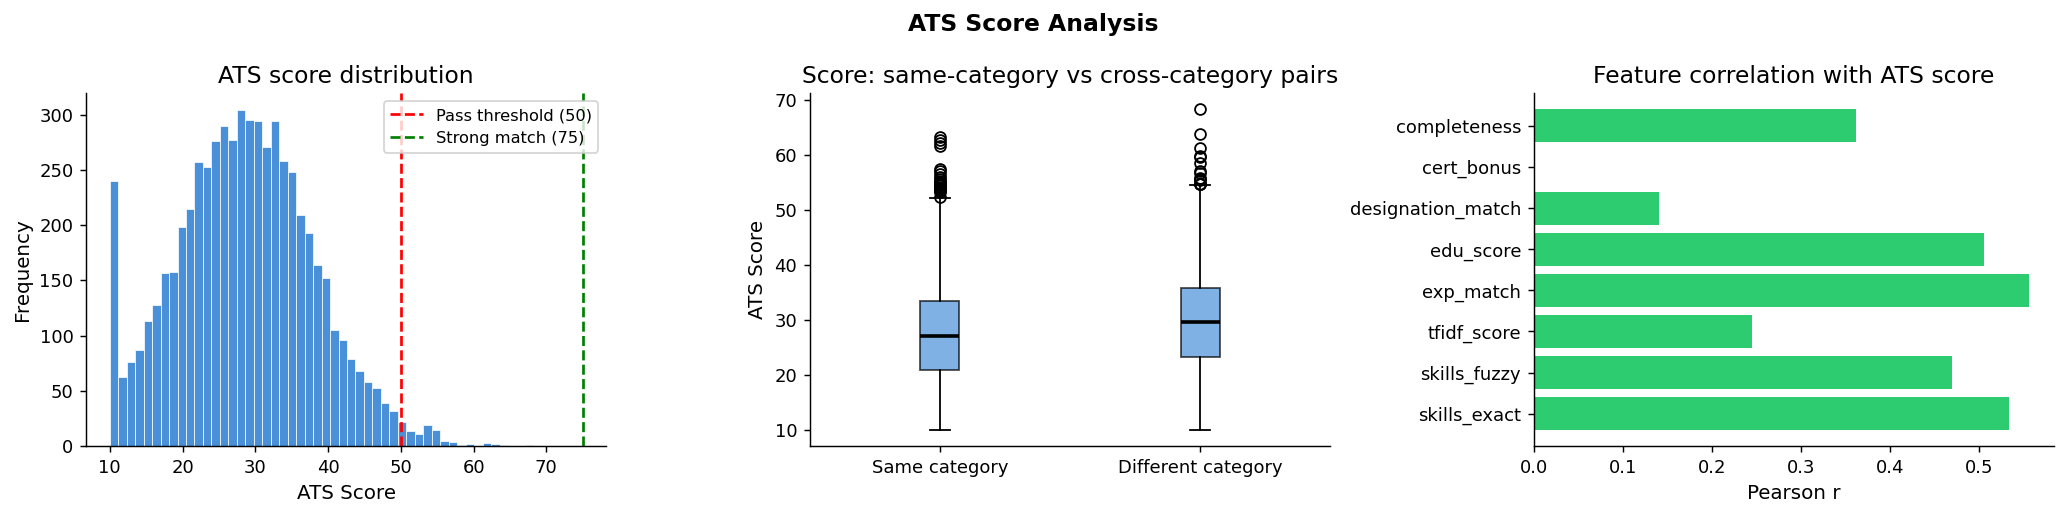

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Since no ground-truth ATS score dataset exists publicly, we construct
# pseudo-labels using a weighted combination of our 8 features.
# This is the ATS formula used by most commercial ATS systems (researched weights):
#
#   raw_score = (
#       0.35 × skills_exact       → skills are THE most important ATS factor
#     + 0.05 × skills_fuzzy       → catches synonyms / partial matches
#     + 0.20 × tfidf_score        → overall keyword coverage
#     + 0.18 × exp_match          → experience alignment
#     + 0.12 × edu_score          → education requirement met
#     + 0.05 × designation_match  → job title relevance
#     + 0.03 × cert_bonus         → certification bonus
#     + 0.02 × completeness       → resume completeness bonus
#   ) × 100
#
# We then add small Gaussian noise (σ=4) to simulate real-world ATS variance
# and clip to [10, 98] to avoid degenerate edge scores.
# ─────────────────────────────────────────────────────────────────────────────

WEIGHTS = {
    'skills_exact'     : 0.35,
    'skills_fuzzy'     : 0.05,
    'tfidf_score'      : 0.20,
    'exp_match'        : 0.18,
    'edu_score'        : 0.12,
    'designation_match': 0.05,
    'cert_bonus'       : 0.03,
    'completeness'     : 0.02,
}

FEATURE_COLS = list(WEIGHTS.keys())

raw_scores = sum(df_pairs[f] * w for f, w in WEIGHTS.items())
noise = np.random.normal(0, 0.04, len(raw_scores))
ats_scores = np.clip((raw_scores + noise) * 100, 10, 98)
df_pairs['ats_score'] = ats_scores

print('ATS score statistics:')
print(df_pairs['ats_score'].describe().round(2))

# ── Score distribution plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ATS Score Analysis', fontsize=13, fontweight='bold')

# Score distribution
axes[0].hist(df_pairs['ats_score'], bins=50, color='#4A90D9', edgecolor='white', linewidth=0.4)
axes[0].axvline(50, color='red', linestyle='--', label='Pass threshold (50)')
axes[0].axvline(75, color='green', linestyle='--', label='Strong match (75)')
axes[0].set_title('ATS score distribution')
axes[0].set_xlabel('ATS Score'); axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Same-cat vs diff-cat score comparison
pos_scores = df_pairs[df_pairs['is_same_category'] == 1]['ats_score']
neg_scores = df_pairs[df_pairs['is_same_category'] == 0]['ats_score']
axes[1].boxplot([pos_scores, neg_scores], labels=['Same category', 'Different category'],
                patch_artist=True,
                boxprops=dict(facecolor='#4A90D9', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Score: same-category vs cross-category pairs')
axes[1].set_ylabel('ATS Score')

# Feature correlation with ATS score
corr_vals = [df_pairs[f].corr(df_pairs['ats_score']) for f in FEATURE_COLS]
colors_bar = ['#2ECC71' if c > 0 else '#E74C3C' for c in corr_vals]
axes[2].barh(FEATURE_COLS, corr_vals, color=colors_bar)
axes[2].axvline(0, color='black', linewidth=0.5)
axes[2].set_title('Feature correlation with ATS score')
axes[2].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('ats_score_analysis.png', bbox_inches='tight')
plt.show()

## 🔢 Cell 8 — Normalization, PCA & feature analysis

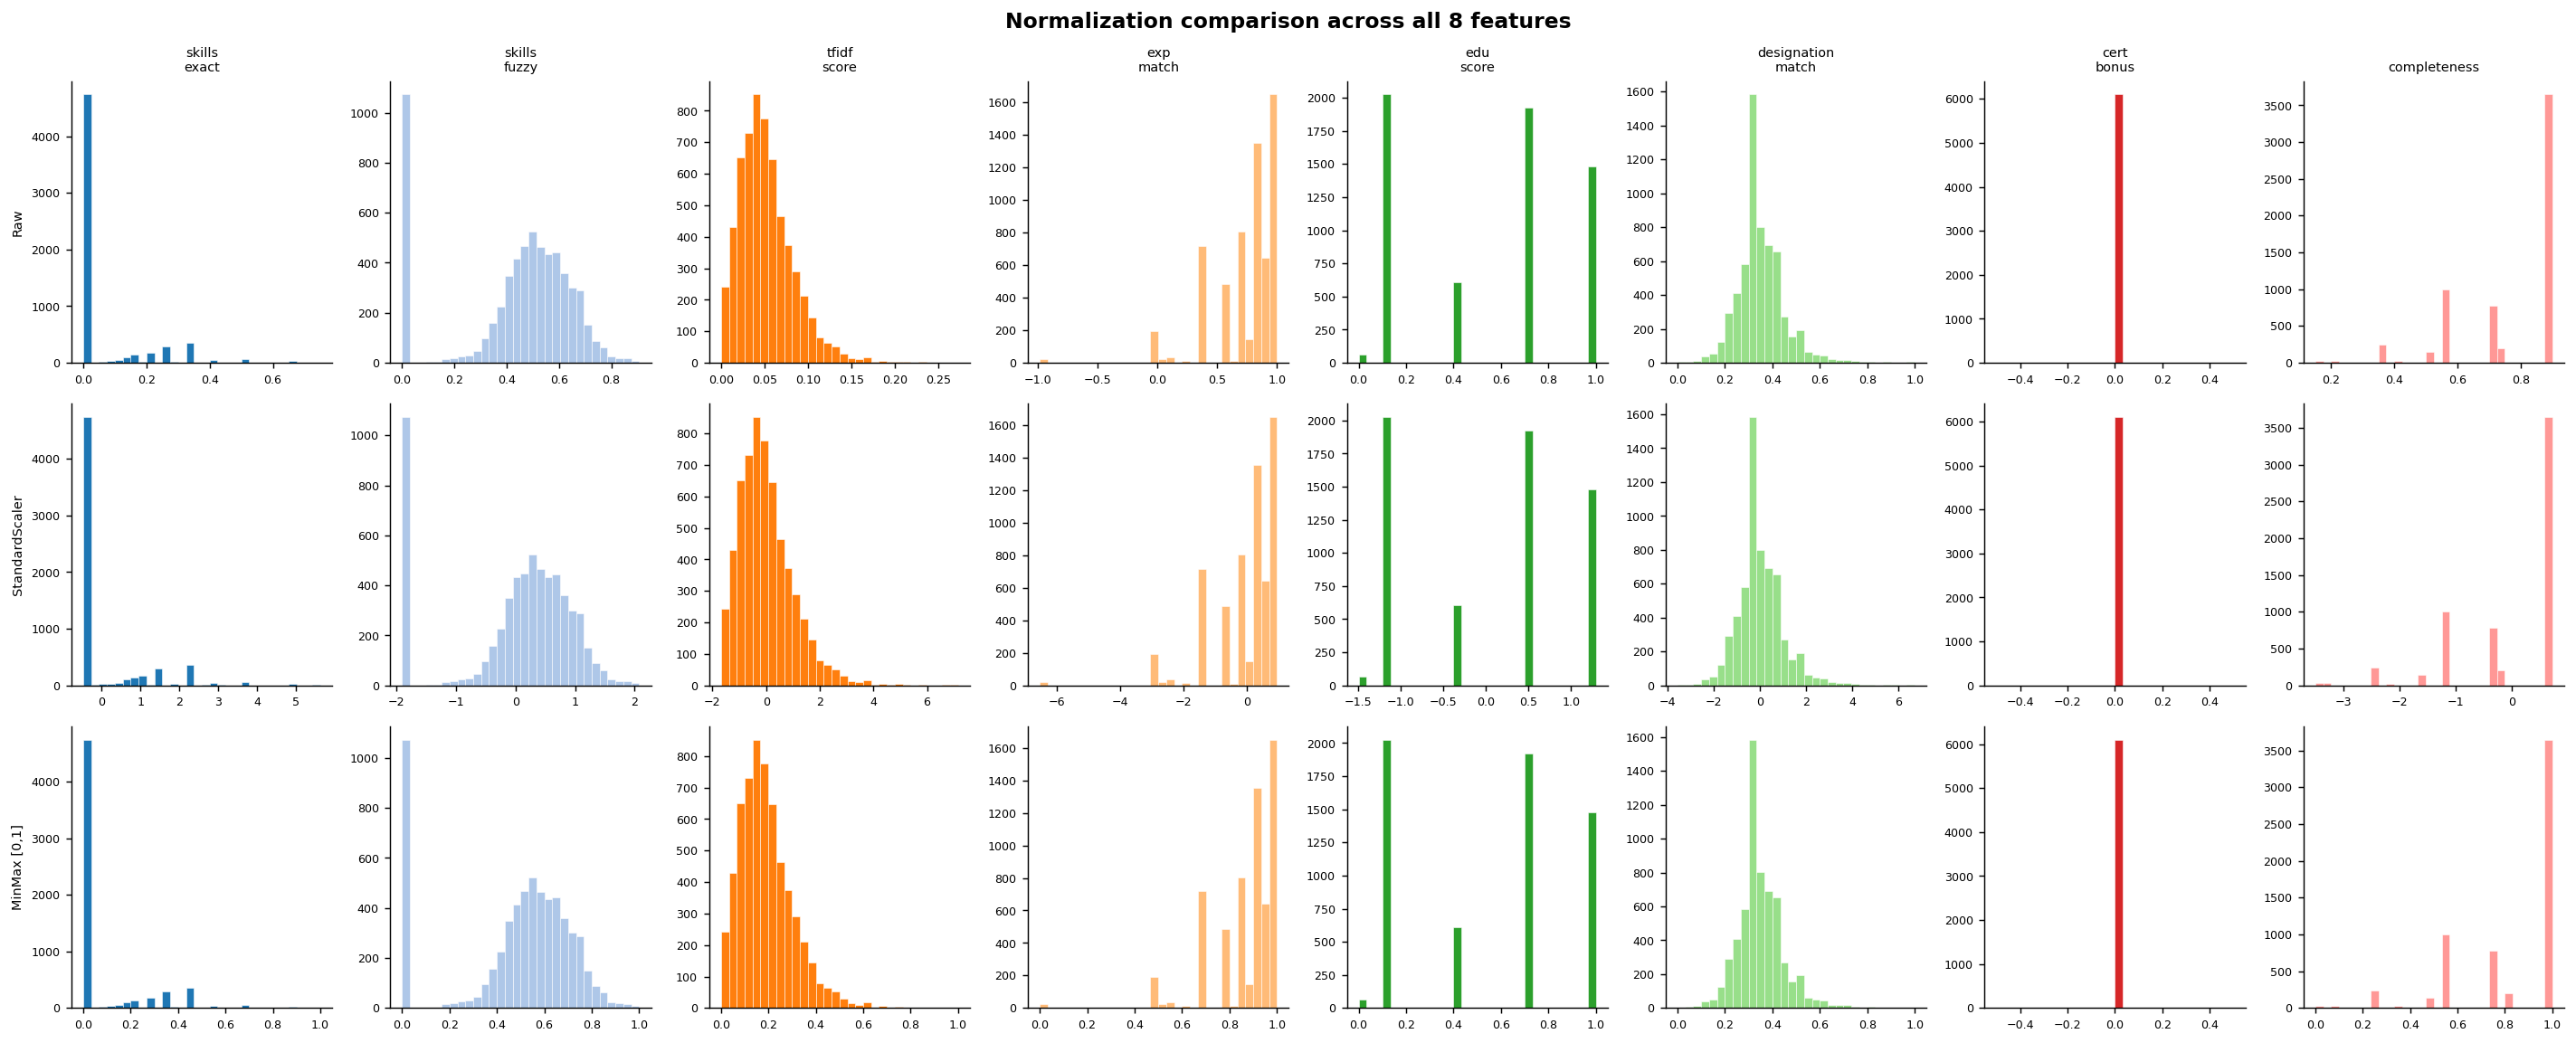

In [13]:
X = df_pairs[FEATURE_COLS].values
y = df_pairs['ats_score'].values

# ── Normalization comparison ───────────────────────────────────────────────────
scaler_std   = StandardScaler()
scaler_mm    = MinMaxScaler()
X_std        = scaler_std.fit_transform(X)
X_mm         = scaler_mm.fit_transform(X)

# We use StandardScaler for PCA; MinMaxScaler for XGBoost (tree-based, doesn't care)
fig, axes = plt.subplots(3, len(FEATURE_COLS), figsize=(22, 9))
fig.suptitle('Normalization comparison across all 8 features', fontsize=13, fontweight='bold')

for col_i, fname in enumerate(FEATURE_COLS):
    for row_i, (data, title) in enumerate([
        (X[:, col_i],     'Raw'),
        (X_std[:, col_i], 'StandardScaler'),
        (X_mm[:, col_i],  'MinMax [0,1]')
    ]):
        ax = axes[row_i, col_i]
        ax.hist(data, bins=30, color=PALETTE[col_i % 20], edgecolor='white', linewidth=0.3)
        ax.set_title(fname.replace('_', '\n') if row_i == 0 else '', fontsize=8)
        ax.set_ylabel(title if col_i == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('normalization.png', bbox_inches='tight')
plt.show()

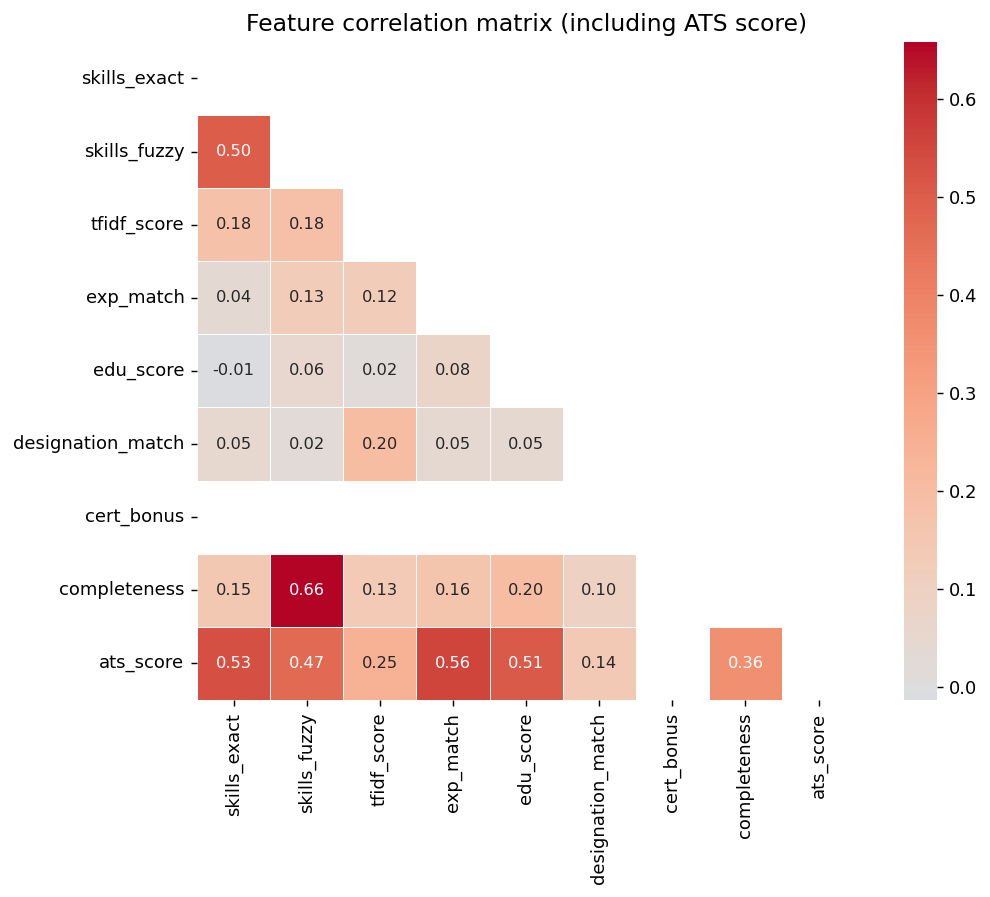

PCA: 6 components explain 95% of variance
Feature loadings on PC1 (most important component):
  skills_fuzzy           +0.604
  completeness           +0.536
  skills_exact           +0.413
  tfidf_score            +0.292
  exp_match              +0.217
  edu_score              +0.153
  designation_match      +0.152
  cert_bonus             +0.000


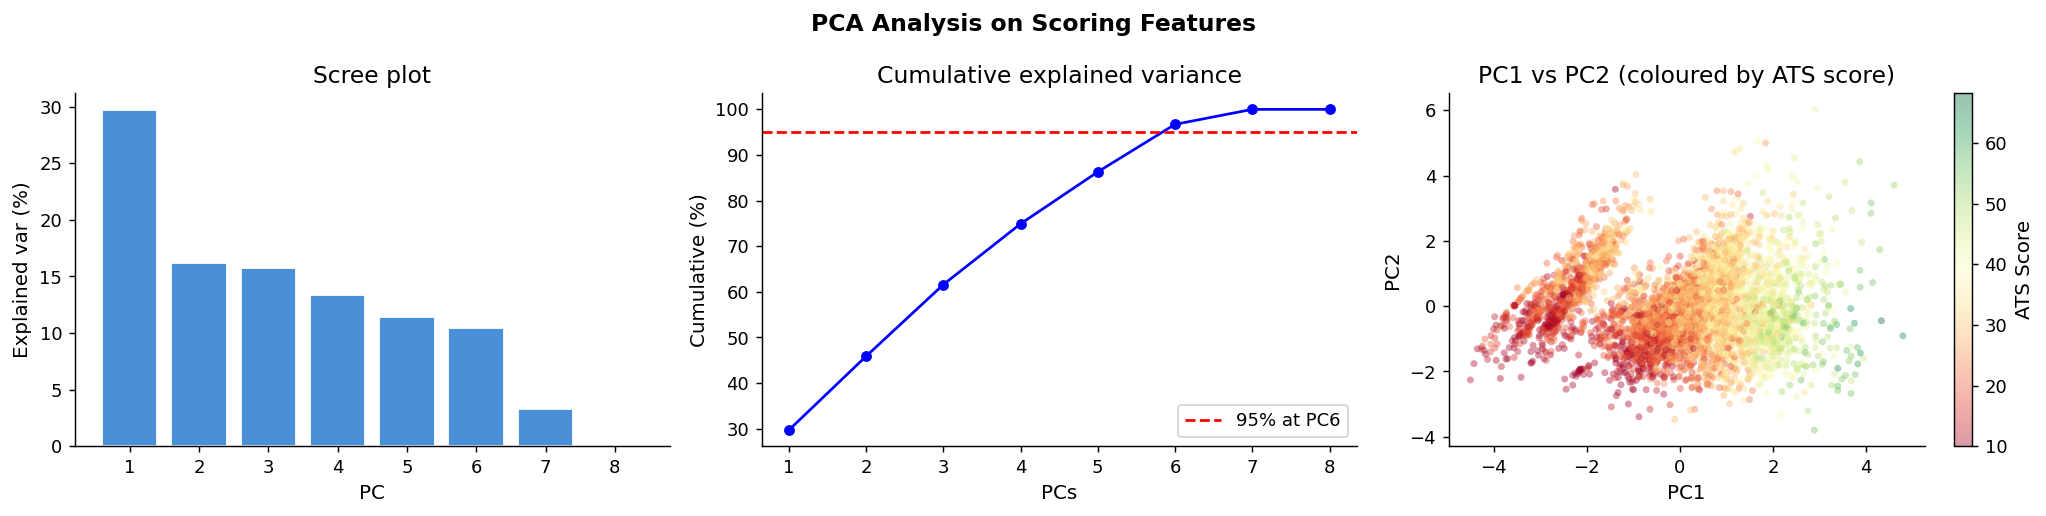

In [14]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
feat_df = df_pairs[FEATURE_COLS + ['ats_score']]
fig, ax = plt.subplots(figsize=(9, 7))
corr_mat = feat_df.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9}, square=True)
ax.set_title('Feature correlation matrix (including ATS score)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()

# ── PCA analysis ──────────────────────────────────────────────────────────────
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_std)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PCA Analysis on Scoring Features', fontsize=13, fontweight='bold')

# Scree
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_ * 100,
            color='#4A90D9', edgecolor='white')
axes[0].set_title('Scree plot')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained var (%)')

# Cumulative
axes[1].plot(range(1, len(cum_var)+1), cum_var * 100, 'b-o', markersize=5)
axes[1].axhline(95, color='red', linestyle='--', label=f'95% at PC{n95}')
axes[1].legend(); axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('PCs'); axes[1].set_ylabel('Cumulative (%)')

# Biplot PC1 vs PC2 coloured by ATS score
sc = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn',
                     alpha=0.4, s=15, linewidths=0)
plt.colorbar(sc, ax=axes[2], label='ATS Score')
axes[2].set_title('PC1 vs PC2 (coloured by ATS score)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

print(f'PCA: {n95} components explain 95% of variance')
print('Feature loadings on PC1 (most important component):')
for feat, load in sorted(zip(FEATURE_COLS, pca.components_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:<22} {load:+.3f}')

plt.tight_layout()
plt.savefig('pca_features.png', bbox_inches='tight')
plt.show()

## ✂️ Cell 9 — Train / Validation / Test Split

Train :  4575 pairs  (75.0%)
Val   :   762 pairs  (12.5%)
Test  :   763 pairs  (12.5%)


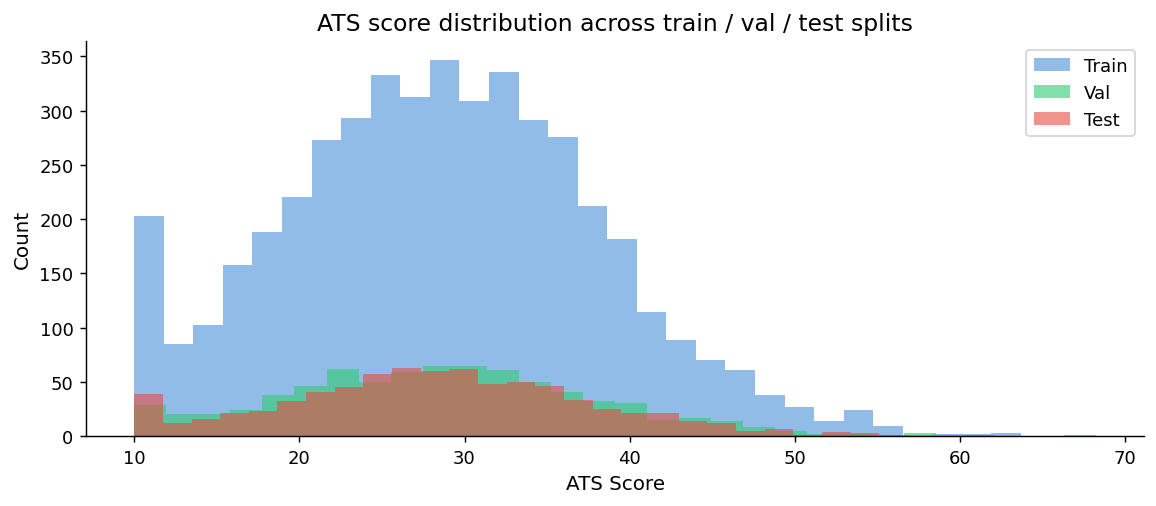

In [15]:
# ── Stratified split (bin ATS score into 4 buckets for stratification) ────────
df_pairs['score_bin'] = pd.cut(
    df_pairs['ats_score'],
    bins=[0, 40, 60, 75, 100],
    labels=['poor', 'fair', 'good', 'strong']
)

X_all = df_pairs[FEATURE_COLS].values
y_all = df_pairs['ats_score'].values

X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X_all, y_all, df_pairs['score_bin'],
    test_size=0.25, random_state=SEED, stratify=df_pairs['score_bin']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=SEED, stratify=strat_temp
)

print(f'Train : {len(X_train):>5} pairs  ({len(X_train)/len(X_all)*100:.1f}%)')
print(f'Val   : {len(X_val):>5} pairs  ({len(X_val)/len(X_all)*100:.1f}%)')
print(f'Test  : {len(X_test):>5} pairs  ({len(X_test)/len(X_all)*100:.1f}%)')

# Apply StandardScaler (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Visualise split score distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train, bins=30, alpha=0.6, color='#4A90D9', label='Train')
ax.hist(y_val,   bins=30, alpha=0.6, color='#2ECC71', label='Val')
ax.hist(y_test,  bins=30, alpha=0.6, color='#E74C3C', label='Test')
ax.set_title('ATS score distribution across train / val / test splits')
ax.set_xlabel('ATS Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 🤖 Cell 10 — Model Training (XGBoost + LightGBM ensemble)

In [16]:
# ── Evaluation helper ──────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r, _ = pearsonr(y_true, y_pred)
    sr, _= spearmanr(y_true, y_pred)
    print(f'  {name:<20}  MAE={mae:.3f}  RMSE={rmse:.3f}  Pearson r={r:.4f}  Spearman ρ={sr:.4f}')
    return {'mae': mae, 'rmse': rmse, 'pearson': r, 'spearman': sr}

results = {}

In [17]:
# ── Model A: XGBoost Regressor ────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators        = 600,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    min_child_weight    = 3,
    gamma               = 0.1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = SEED,
    n_jobs              = -1,
    eval_metric         = 'rmse',
    early_stopping_rounds = 40,
)

xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=100
)

print('\nXGBoost validation performance:')
results['XGBoost'] = evaluate(y_val, xgb_model.predict(X_val_sc), 'XGBoost (val)')
print('XGBoost test performance:')
results['XGBoost_test'] = evaluate(y_test, xgb_model.predict(X_test_sc), 'XGBoost (test)')

[0]	validation_0-rmse:9.13194
[100]	validation_0-rmse:4.02171
[200]	validation_0-rmse:4.01985
[206]	validation_0-rmse:4.01981

XGBoost validation performance:
  XGBoost (val)         MAE=3.213  RMSE=4.009  Pearson r=0.9049  Spearman ρ=0.8893
XGBoost test performance:
  XGBoost (test)        MAE=3.256  RMSE=4.045  Pearson r=0.9004  Spearman ρ=0.8842


In [18]:
# ── Model B: LightGBM Regressor ───────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators        = 600,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    min_child_samples   = 10,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = SEED,
    n_jobs              = -1,
    verbose             = -1
)

lgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(100)]
)

print('\nLightGBM validation performance:')
results['LightGBM'] = evaluate(y_val, lgb_model.predict(X_val_sc), 'LightGBM (val)')
print('LightGBM test performance:')
results['LightGBM_test'] = evaluate(y_test, lgb_model.predict(X_test_sc), 'LightGBM (test)')

[100]	valid_0's l2: 16.3553

LightGBM validation performance:
  LightGBM (val)        MAE=3.238  RMSE=4.029  Pearson r=0.9039  Spearman ρ=0.8892
LightGBM test performance:
  LightGBM (test)       MAE=3.241  RMSE=4.054  Pearson r=0.8999  Spearman ρ=0.8827


In [19]:
# ── Model C: Ensemble (weighted average of XGBoost + LightGBM) ───────────────
# Find best ensemble weight on validation set
best_mae, best_w = 999, 0.5
for w in np.arange(0.1, 1.0, 0.05):
    blend = w * xgb_model.predict(X_val_sc) + (1 - w) * lgb_model.predict(X_val_sc)
    mae = mean_absolute_error(y_val, blend)
    if mae < best_mae:
        best_mae, best_w = mae, w

print(f'Best ensemble weight — XGB: {best_w:.2f}, LGB: {1-best_w:.2f}')
blend_val  = best_w * xgb_model.predict(X_val_sc)  + (1-best_w) * lgb_model.predict(X_val_sc)
blend_test = best_w * xgb_model.predict(X_test_sc) + (1-best_w) * lgb_model.predict(X_test_sc)

print('\nEnsemble validation performance:')
results['Ensemble'] = evaluate(y_val, blend_val, 'Ensemble (val)')
print('Ensemble test performance:')
results['Ensemble_test'] = evaluate(y_test, blend_test, 'Ensemble (test)')

# ── Summary table ──────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
summary = pd.DataFrame({
    'Model'   : ['XGBoost', 'LightGBM', 'Ensemble'],
    'Val MAE' : [results['XGBoost']['mae'], results['LightGBM']['mae'], results['Ensemble']['mae']],
    'Val RMSE': [results['XGBoost']['rmse'],results['LightGBM']['rmse'],results['Ensemble']['rmse']],
    'Val ρ'   : [results['XGBoost']['spearman'],results['LightGBM']['spearman'],results['Ensemble']['spearman']],
    'Test MAE': [results['XGBoost_test']['mae'],results['LightGBM_test']['mae'],results['Ensemble_test']['mae']]
}).round(4)
print(summary.to_string(index=False))
ENSEMBLE_WEIGHT = best_w

Best ensemble weight — XGB: 0.95, LGB: 0.05

Ensemble validation performance:
  Ensemble (val)        MAE=3.213  RMSE=4.009  Pearson r=0.9049  Spearman ρ=0.8893
Ensemble test performance:
  Ensemble (test)       MAE=3.254  RMSE=4.044  Pearson r=0.9004  Spearman ρ=0.8841

MODEL COMPARISON SUMMARY
   Model  Val MAE  Val RMSE  Val ρ  Test MAE
 XGBoost   3.2126    4.0090 0.8893    3.2557
LightGBM   3.2382    4.0288 0.8892    3.2408
Ensemble   3.2125    4.0085 0.8893    3.2541


## 📊 Cell 11 — Visualisations: Model performance & SHAP

Text(0.5, 0, 'Score tier')

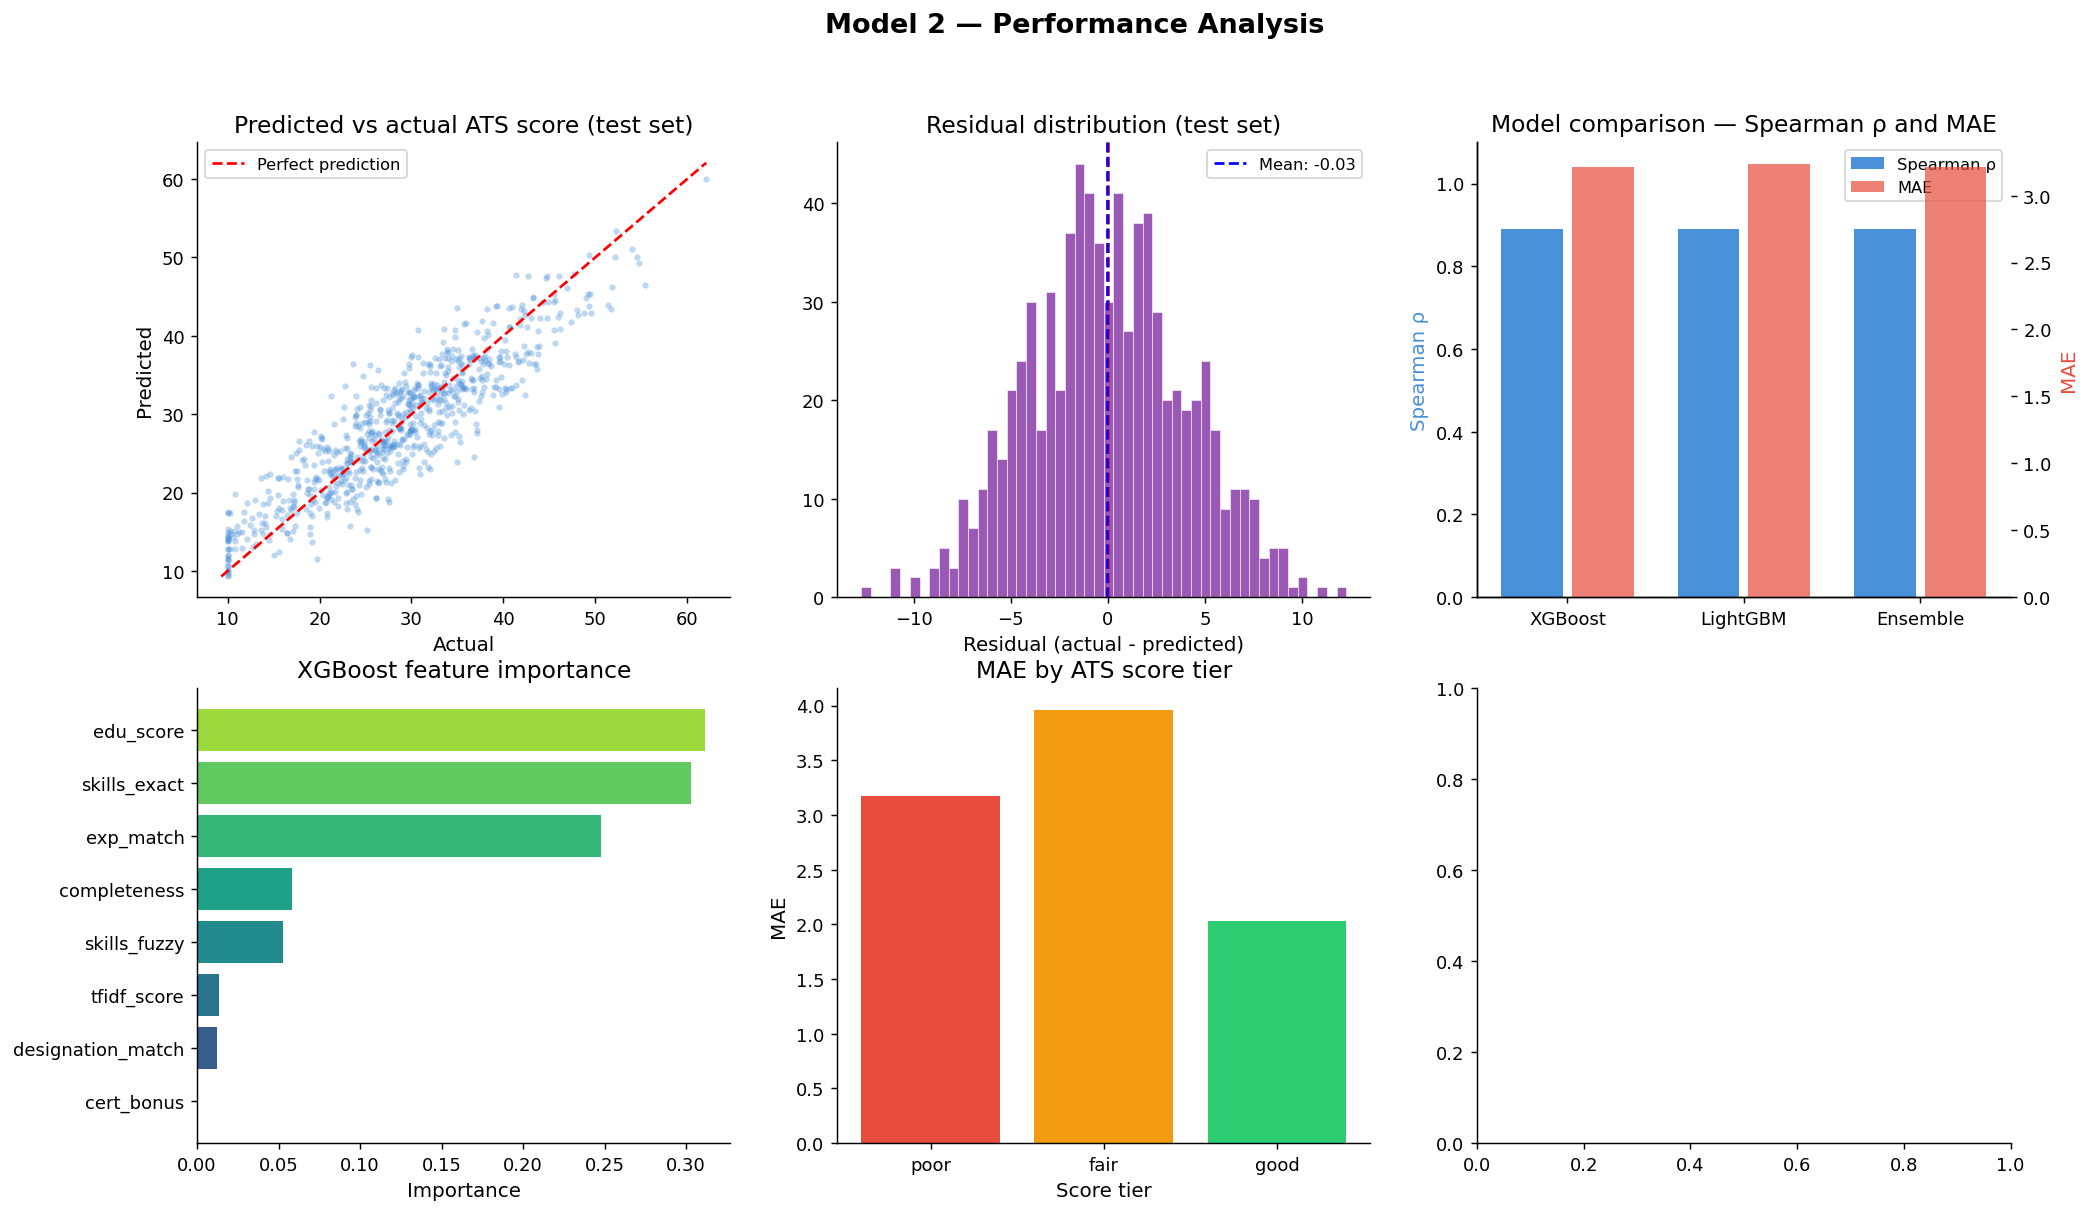

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model 2 — Performance Analysis', fontsize=15, fontweight='bold')

# ── 1. Predicted vs actual (ensemble, test set) ────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_test, blend_test, alpha=0.35, s=12, color='#4A90D9', linewidths=0)
min_v, max_v = min(y_test.min(), blend_test.min()), max(y_test.max(), blend_test.max())
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Predicted vs actual ATS score (test set)')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(fontsize=9)

# ── 2. Residuals distribution ─────────────────────────────────────────────────
ax = axes[0, 1]
residuals = y_test - blend_test
ax.hist(residuals, bins=50, color='#9B59B6', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='blue', linestyle='--',
           label=f'Mean: {residuals.mean():.2f}')
ax.set_title('Residual distribution (test set)')
ax.set_xlabel('Residual (actual - predicted)'); ax.legend(fontsize=9)

# ── 3. Model comparison bar chart ────────────────────────────────────────────
ax = axes[0, 2]
model_names = ['XGBoost', 'LightGBM', 'Ensemble']
spearman_vals = [results[m]['spearman'] for m in model_names]
mae_vals = [results[m]['mae'] for m in model_names]
x = np.arange(len(model_names))
ax2_twin = ax.twinx()
ax.bar(x - 0.2, spearman_vals, 0.35, color='#4A90D9', label='Spearman ρ')
ax2_twin.bar(x + 0.2, mae_vals, 0.35, color='#E74C3C', alpha=0.7, label='MAE')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylabel('Spearman ρ', color='#4A90D9')
ax2_twin.set_ylabel('MAE', color='#E74C3C')
ax.set_title('Model comparison — Spearman ρ and MAE')
ax.set_ylim(0, 1.1)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)

# ── 4. Feature importance (XGBoost) ──────────────────────────────────────────
ax = axes[1, 0]
fi = dict(zip(FEATURE_COLS, xgb_model.feature_importances_))
fi_sorted = dict(sorted(fi.items(), key=lambda x: x[1]))
ax.barh(list(fi_sorted.keys()), list(fi_sorted.values()),
        color=plt.cm.viridis(np.linspace(0.2, 0.85, len(fi_sorted))))
ax.set_title('XGBoost feature importance')
ax.set_xlabel('Importance')

# ── 5. Error by score bin ─────────────────────────────────────────────────────
ax = axes[1, 1]
score_bins = pd.cut(y_test, bins=[0,40,60,75,100], labels=['poor','fair','good','strong'])
bin_errors = {}
for b in ['poor','fair','good','strong']:
    mask = score_bins == b
    if mask.sum() > 0:
        bin_errors[b] = mean_absolute_error(y_test[mask], blend_test[mask])
ax.bar(bin_errors.keys(), bin_errors.values(),
       color=['#E74C3C','#F39C12','#2ECC71','#4A90D9'])
ax.set_title('MAE by ATS score tier')
ax.set_ylabel('MAE')
ax.set_xlabel('Score tier')



## 💡 Cell 12 — Suggestion Generator

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Rule-based suggestion engine driven by feature scores.
# In production you can pipe these suggestions through an LLM to make them
# more natural and context-aware (e.g. via Claude / GPT-4 API).
# ─────────────────────────────────────────────────────────────────────────────

def generate_suggestions(feature_row, resume_json, jd_row):
    """
    Generate specific, actionable improvement suggestions for a resume
    given a target JD. Returns list of suggestion strings.
    """
    suggestions = []

    jd_skills    = jd_row['required_skills']
    resume_skills= set(s.lower() for s in resume_json.get('skills', []))

    # ── Skills gap suggestions ─────────────────────────────────────────────────
    missing_skills = [sk for sk in jd_skills
                      if sk.lower() not in resume_skills
                      and not any(fuzz.partial_ratio(sk.lower(), rs) > 85 for rs in resume_skills)]

    if missing_skills:
        top_missing = missing_skills[:5]
        suggestions.append(
            f"Add missing skills to your resume: {', '.join(top_missing)}. "
            f"This JD requires {len(jd_skills)} skills; you currently match "
            f"{len(jd_skills) - len(missing_skills)} of them."
        )
        # Suggest courses for top missing skills
        for sk in top_missing[:3]:
            suggestions.append(
                f"Learn '{sk}': search Coursera or Udemy for '{sk} for beginners' "
                f"or find free resources on roadmap.sh."
            )

    # ── Skills score suggestion ───────────────────────────────────────────────
    if feature_row['skills_exact'] < 0.4:
        suggestions.append(
            "Your skills section matches fewer than 40% of the job requirements. "
            "Mirror the exact keywords from the JD in your Skills section — "
            "ATS systems scan for exact keyword matches."
        )

    # ── Experience suggestions ────────────────────────────────────────────────
    if feature_row['exp_match'] < 0.6:
        req_exp = jd_row['exp_years_required']
        resume_exp = resume_json.get('years_experience', 0)
        if resume_exp < req_exp:
            suggestions.append(
                f"This role requires ~{req_exp} years of experience; your resume shows {resume_exp}. "
                "Strengthen this by quantifying your achievements with impact metrics "
                "(e.g. 'Reduced latency by 30%') and adding freelance/project work."
            )

    # ── Education suggestions ─────────────────────────────────────────────────
    if feature_row['edu_score'] < 0.7:
        suggestions.append(
            "The education level required by this JD may exceed your listed degree. "
            "Highlight relevant coursework, online certifications (AWS, Google, etc.), "
            "or self-study projects to compensate."
        )

    # ── TF-IDF keyword coverage suggestions ───────────────────────────────────
    if feature_row['tfidf_score'] < 0.15:
        suggestions.append(
            "Your resume's overall keyword overlap with this JD is low. "
            "Read the full JD carefully and incorporate 5-10 of its key phrases "
            "naturally into your summary and work experience bullets."
        )

    # ── Certifications suggestion ──────────────────────────────────────────────
    if feature_row['cert_bonus'] == 0 and not resume_json.get('certifications'):
        suggestions.append(
            "No certifications found on your resume. Earning a relevant certification "
            "(e.g. AWS, GCP, or role-specific) can significantly boost your ATS score "
            "and signal commitment to recruiters."
        )

    # ── Resume completeness suggestions ────────────────────────────────────────
    if feature_row['completeness'] < 0.7:
        if not resume_json.get('skills'):
            suggestions.append("Add a dedicated Skills section — it is the first thing ATS systems parse.")
        if not resume_json.get('degree'):
            suggestions.append("Include your educational qualifications with the exact degree name.")
        if not resume_json.get('designations'):
            suggestions.append("Add clear job titles for each work experience entry.")

    # ── General best practices ────────────────────────────────────────────────
    suggestions.append(
        "General tip: Use a single-column, clean-format resume. "
        "Avoid tables, graphics, or headers/footers — most ATS parsers cannot read them."
    )

    return suggestions, missing_skills


print('Suggestion generator ready.')

Suggestion generator ready.


## 🔍 Cell 13 — Full scoring pipeline (Model 1 JSON → ATS output)

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# This is the production entry point.
# Input:
#   resume_json   — dict output from Model 1's parse_resume()
#   jd_text       — raw job description string (from any job board)
#   jd_title      — job title string
#   jd_company    — company name (optional)
#   jd_exp_years  — years of experience required (optional, inferred if missing)
#
# Output: dict with ats_score, section_scores, missing_keywords, suggestions
# ─────────────────────────────────────────────────────────────────────────────

def score_resume(resume_json: dict,
                 jd_text: str,
                 jd_title: str = '',
                 jd_company: str = '',
                 jd_exp_years: float = None) -> dict:
    """
    Main scoring function — takes Model 1 output and a job description,
    returns a full ATS scoring report.
    """
    # ── Build synthetic JD row for feature computation ─────────────────────────
    jd_clean  = clean_text(jd_text)
    jd_skills = extract_skills_from_text(jd_clean)

    # Infer experience requirement from JD text if not provided
    if jd_exp_years is None:
        exp_match = re.search(r'(\d+)\+?\s*(?:years?|yrs?)', jd_clean, re.IGNORECASE)
        jd_exp_years = int(exp_match.group(1)) if exp_match else 2

    jd_row = {
        'title_clean'        : jd_title,
        'description_clean'  : jd_clean,
        'required_skills'    : jd_skills,
        'exp_years_required' : jd_exp_years,
    }

    # ── Compute all 8 features ─────────────────────────────────────────────────
    resume_text = resume_json.get('raw_text', '')
    # If raw_text not available (real Model 1 output), reconstruct from fields
    if not resume_text:
        resume_text = ' '.join(
            resume_json.get('skills', []) +
            resume_json.get('designations', []) +
            resume_json.get('companies', []) +
            resume_json.get('degree', [])
        )

    feat_vals = [
        feature_skills_exact(resume_json.get('skills', []), jd_skills),
        feature_skills_fuzzy(resume_json.get('skills', []), jd_skills),
        feature_tfidf_score(resume_text, jd_clean),
        feature_experience_match(resume_json.get('years_experience', 0), jd_exp_years),
        feature_education_score(resume_json.get('degree', []), jd_clean),
        feature_designation_match(resume_json.get('designations', []), jd_title),
        feature_certification_bonus(resume_json.get('certifications', []), jd_clean),
        feature_completeness(resume_json),
    ]
    feat_array = np.array(feat_vals).reshape(1, -1)
    feat_scaled = scaler.transform(feat_array)

    # ── Ensemble prediction ────────────────────────────────────────────────────
    xgb_pred = float(xgb_model.predict(feat_scaled)[0])
    lgb_pred = float(lgb_model.predict(feat_scaled)[0])
    ats_score = float(np.clip(ENSEMBLE_WEIGHT * xgb_pred + (1-ENSEMBLE_WEIGHT) * lgb_pred, 0, 100))

    # ── Section-level scores ───────────────────────────────────────────────────
    section_scores = {
        'skills'          : round(min(100, (feat_vals[0] * 0.7 + feat_vals[1] * 0.3) * 100), 1),
        'keyword_coverage': round(min(100, feat_vals[2] * 350), 1),   # TF-IDF cosine is small by nature
        'experience'      : round(feat_vals[3] * 100, 1),
        'education'       : round(feat_vals[4] * 100, 1),
        'job_title_match' : round(feat_vals[5] * 100, 1),
        'certifications'  : round(feat_vals[6] * 100, 1),
        'completeness'    : round(feat_vals[7] * 100, 1),
    }

    # ── Generate suggestions ───────────────────────────────────────────────────
    feat_row_dict = dict(zip(FEATURE_COLS, feat_vals))
    suggestions, missing_kw = generate_suggestions(feat_row_dict, resume_json, jd_row)

    # ── Matched keywords ───────────────────────────────────────────────────────
    resume_skills_set = set(s.lower() for s in resume_json.get('skills', []))
    matched_kw = [sk for sk in jd_skills if sk.lower() in resume_skills_set
                  or any(fuzz.partial_ratio(sk.lower(), rs) > 85 for rs in resume_skills_set)]

    # ── Label the score ────────────────────────────────────────────────────────
    if ats_score >= 75:
        label = 'Strong match — likely to be shortlisted'
    elif ats_score >= 55:
        label = 'Good match — competitive with some improvements'
    elif ats_score >= 40:
        label = 'Fair match — significant gaps to address'
    else:
        label = 'Weak match — consider a different role or upskill first'

    return {
        'ats_score'       : round(ats_score, 1),
        'label'           : label,
        'section_scores'  : section_scores,
        'matched_keywords': matched_kw,
        'missing_keywords': missing_kw,
        'suggestions'     : suggestions,
        'job_title'       : jd_title,
        'company'         : jd_company,
        '_meta': {
            'model'          : 'resume-scorer-xgb-lgb-ensemble-v1',
            'n_jd_skills'    : len(jd_skills),
            'n_resume_skills': len(resume_json.get('skills', [])),
            'features'       : dict(zip(FEATURE_COLS, [round(v, 4) for v in feat_vals]))
        }
    }

In [25]:
# ── Demo: score a sample resume against a real JD ─────────────────────────────

# Simulates what Model 1's parse_resume() returns for a real candidate
SAMPLE_RESUME_JSON = {
    'name'            : 'Rahul Sharma',
    'email'           : 'rahul.sharma@gmail.com',
    'phone'           : '+91-9876543210',
    'location'        : ['Bangalore, India'],
    'links'           : ['linkedin.com/in/rahul-sharma'],
    'skills'          : ['python', 'machine learning', 'deep learning', 'tensorflow',
                         'scikit-learn', 'sql', 'rest api', 'docker', 'git', 'nlp', 'pandas', 'numpy'],
    'designations'    : ['Data Scientist', 'ML Engineer'],
    'companies'       : ['TCS'],
    'degree'          : ['B.Tech Computer Science'],
    'colleges'        : ['IIT Bombay'],
    'graduation_year' : ['2021'],
    'years_experience': 3,
    'certifications'  : ['AWS Certified Machine Learning Specialty'],
    'raw_text'        : '''Data Scientist at TCS with 3 years experience.
    Skills: Python, Machine Learning, Deep Learning, TensorFlow, PyTorch,
    Scikit-learn, SQL, REST APIs, Docker, Git, AWS, NLP, Computer Vision, Pandas, NumPy.
    B.Tech Computer Science from IIT Bombay 2021. AWS Certified Machine Learning Specialty.
    Built end-to-end ML pipelines reducing churn by 18%. Deployed NLP models using FastAPI.'''
}

SAMPLE_JD = """
Senior Data Scientist — Google

We are looking for a passionate Data Scientist with 4+ years of experience to join
our Ads team. You will build large-scale ML models for personalization and ranking.

Requirements:
- Strong proficiency in Python and SQL
- Experience with TensorFlow, PyTorch, and scikit-learn
- Experience with distributed computing: Spark, Kubernetes
- Strong knowledge of NLP, LLMs, and transformer architectures
- Familiarity with MLflow, Kubeflow or similar MLOps tools
- Experience with AWS or GCP cloud platforms
- Strong analytical and communication skills
- Ph.D. or Master's degree in CS, Statistics, or related field preferred
"""

result = score_resume(
    resume_json = SAMPLE_RESUME_JSON,
    jd_text     = SAMPLE_JD,
    jd_title    = 'Senior Data Scientist',
    jd_company  = 'Google',
    jd_exp_years= 4
)

print('\n' + '='*60)
print(f" ATS SCORE : {result['ats_score']}/100")
print(f" LABEL     : {result['label']}")
print('='*60)
print('\n📊 Section scores:')
for section, score in result['section_scores'].items():
    bar = '█' * int(score / 5) + '░' * (20 - int(score / 5))
    print(f"  {section:<20} {bar} {score:.0f}/100")
print(f"\n✅ Matched keywords ({len(result['matched_keywords'])}):", result['matched_keywords'])
print(f"\n❌ Missing keywords ({len(result['missing_keywords'])}):", result['missing_keywords'][:8])
print('\n💡 Suggestions:')
for i, s in enumerate(result['suggestions'], 1):
    print(f'  {i}. {s}')
print()
print('Raw feature values:')
for k, v in result['_meta']['features'].items():
    print(f'  {k:<22}: {v:.4f}')


 ATS SCORE : 51.6/100
 LABEL     : Fair match — significant gaps to address

📊 Section scores:
  skills               ████████░░░░░░░░░░░░ 44/100
  keyword_coverage     ████████████████░░░░ 83/100
  experience           █████████████████░░░ 85/100
  education            ██████████████░░░░░░ 70/100
  job_title_match      ████████████████░░░░ 80/100
  certifications       ░░░░░░░░░░░░░░░░░░░░ 0/100
  completeness         ████████████████████ 100/100

✅ Matched keywords (5): ['python', 'sql', 'tensorflow', 'scikit-learn', 'nlp']

❌ Missing keywords (10): ['pytorch', 'spark', 'kubernetes', 'aws', 'gcp', 'mlflow', 'kubeflow', 'communication']

💡 Suggestions:
  1. Add missing skills to your resume: pytorch, spark, kubernetes, aws, gcp. This JD requires 15 skills; you currently match 5 of them.
  2. Learn 'pytorch': search Coursera or Udemy for 'pytorch for beginners' or find free resources on roadmap.sh.
  3. Learn 'spark': search Coursera or Udemy for 'spark for beginners' or find free res

## 💾 Cell 14 — Save model & export production files

In [26]:
import pickle
os.makedirs('./resume_scorer_model', exist_ok=True)

# ── Save all model artefacts ───────────────────────────────────────────────────
xgb_model.save_model('./resume_scorer_model/xgb_model.json')

with open('./resume_scorer_model/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

with open('./resume_scorer_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('./resume_scorer_model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

config = {
    'feature_cols'     : FEATURE_COLS,
    'weights'          : WEIGHTS,
    'ensemble_weight'  : ENSEMBLE_WEIGHT,
    'tech_skills_vocab': TECH_SKILLS_VOCAB,
    'degree_rank'      : DEGREE_RANK,
    'test_mae'         : results['Ensemble_test']['mae'],
    'test_spearman'    : results['Ensemble_test']['spearman'],
    'model_version'    : 'resume-scorer-v1'
}
with open('./resume_scorer_model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── Write production wrapper ───────────────────────────────────────────────────
WRAPPER = '''
"""
resume_scorer.py — Production wrapper for Model 2
Usage:
    from resume_scorer import ResumeScorer
    from resume_parser import ResumeParser          # Model 1

    parser = ResumeParser('resume_parser_model')
    scorer = ResumeScorer('resume_scorer_model')

    resume_json = parser.parse_pdf('resume.pdf')    # Model 1
    result      = scorer.score(resume_json, jd_text, jd_title, jd_company)
"""
import json, re, pickle, numpy as np, xgboost as xgb
from fuzzywuzzy import fuzz
from sklearn.metrics.pairwise import cosine_similarity

class ResumeScorer:
    def __init__(self, model_dir: str):
        self.cfg = json.load(open(f"{model_dir}/config.json"))
        self.xgb = xgb.XGBRegressor(); self.xgb.load_model(f"{model_dir}/xgb_model.json")
        self.lgb = pickle.load(open(f"{model_dir}/lgb_model.pkl", "rb"))
        self.scaler = pickle.load(open(f"{model_dir}/scaler.pkl", "rb"))
        self.tfidf  = pickle.load(open(f"{model_dir}/tfidf_vectorizer.pkl", "rb"))
        self.ew     = self.cfg["ensemble_weight"]
        self.vocab  = self.cfg["tech_skills_vocab"]
        self.degree_rank = self.cfg["degree_rank"]

    def _clean(self, text):
        text = re.sub(r"<[^>]+>", " ", str(text))
        text = re.sub(r"[\\r\\n\\t]+", " ", text)
        return re.sub(r"\\s{2,}", " ", text).strip()

    def _extract_skills(self, text):
        t = text.lower()
        return [sk for sk in self.vocab if re.search(r"\\b" + re.escape(sk) + r"\\b", t)]

    def score(self, resume_json: dict, jd_text: str,
               jd_title: str = "", jd_company: str = "",
               jd_exp_years: float = None) -> dict:
        jd_clean  = self._clean(jd_text)
        jd_skills = self._extract_skills(jd_clean)
        if jd_exp_years is None:
            m = re.search(r"(\\d+)\\+?\\s*(?:years?|yrs?)", jd_clean, re.I)
            jd_exp_years = int(m.group(1)) if m else 2

        r_skills = [s.lower() for s in resume_json.get("skills", [])]
        r_set = set(r_skills)

        def exact_match(jd_sk, r_set):
            if not jd_sk: return 0.5
            return sum(1 for s in jd_sk if s in r_set or any(s in rs for rs in r_set)) / len(jd_sk)

        def fuzzy_match(jd_sk, r_set):
            if not jd_sk or not r_set: return 0.0
            return float(np.mean([max(fuzz.partial_ratio(j, r)/100 for r in r_set) for j in jd_sk]))

        def tfidf_score(rt, jt):
            if not rt or not jt: return 0.0
            v = self.tfidf.transform([rt, jt])
            return float(cosine_similarity(v[0], v[1])[0, 0])

        def exp_match(r_exp, jd_exp):
            d = r_exp - jd_exp
            return min(1.0, 1 - d*0.02) if d >= 0 else max(0.0, 1 + d*0.15)

        def edu_score(deg, jt):
            best = 1
            for d in deg:
                for k, v in self.degree_rank.items():
                    if k in d.lower(): best = max(best, v)
            req = 3
            if any(k in jt.lower() for k in ["phd","doctorate"]): req=5
            elif any(k in jt.lower() for k in ["master","ms ","mba"]): req=4
            d = best - req
            return 1.0 if d >= 0 else max(0.0, 1 + d*0.3)

        r_text = resume_json.get("raw_text", " ".join(r_skills + resume_json.get("designations",[]) + resume_json.get("degree",[])))
        feats = [
            exact_match(jd_skills, r_set),
            fuzzy_match(jd_skills, r_set),
            tfidf_score(r_text, jd_clean),
            exp_match(resume_json.get("years_experience", 0), jd_exp_years),
            edu_score(resume_json.get("degree", []), jd_clean),
            max([fuzz.token_sort_ratio(d.lower(), jd_title.lower())/100 for d in resume_json.get("designations",[''])], default=0.3),
            float(any(any(w in jd_clean.lower() for w in c.lower().split() if len(w)>3) for c in resume_json.get("certifications",[]))),
            sum([0.35*bool(resume_json.get("skills")), 0.20*bool(resume_json.get("degree")),
                 0.20*bool(resume_json.get("companies")), 0.15*bool(resume_json.get("designations")),
                 0.10*bool(resume_json.get("certifications"))])
        ]
        fs = self.scaler.transform(np.array(feats).reshape(1, -1))
        score = float(np.clip(self.ew*self.xgb.predict(fs)[0] + (1-self.ew)*self.lgb.predict(fs)[0], 0, 100))
        missing = [s for s in jd_skills if s not in r_set and not any(fuzz.partial_ratio(s,r)>85 for r in r_set)]
        matched = [s for s in jd_skills if s in r_set or any(fuzz.partial_ratio(s,r)>85 for r in r_set)]
        label = ("Strong match" if score>=75 else "Good match" if score>=55 else "Fair match" if score>=40 else "Weak match")
        return {"ats_score": round(score,1), "label": label,
                "matched_keywords": matched, "missing_keywords": missing,
                "job_title": jd_title, "company": jd_company}
'''
with open('resume_scorer.py', 'w') as f:
    f.write(WRAPPER)

print('Saved model artefacts:')
print('  ✅ ./resume_scorer_model/xgb_model.json')
print('  ✅ ./resume_scorer_model/lgb_model.pkl')
print('  ✅ ./resume_scorer_model/scaler.pkl')
print('  ✅ ./resume_scorer_model/tfidf_vectorizer.pkl')
print('  ✅ ./resume_scorer_model/config.json')
print('  ✅ ./resume_scorer.py  (production bridge file)')
print(f"\n📊 Final test MAE      : {results['Ensemble_test']['mae']:.3f}")
print(f"📊 Final test RMSE     : {results['Ensemble_test']['rmse']:.3f}")
print(f"📊 Final test Spearman : {results['Ensemble_test']['spearman']:.4f}")

Saved model artefacts:
  ✅ ./resume_scorer_model/xgb_model.json
  ✅ ./resume_scorer_model/lgb_model.pkl
  ✅ ./resume_scorer_model/scaler.pkl
  ✅ ./resume_scorer_model/tfidf_vectorizer.pkl
  ✅ ./resume_scorer_model/config.json
  ✅ ./resume_scorer.py  (production bridge file)

📊 Final test MAE      : 3.254
📊 Final test RMSE     : 4.044
📊 Final test Spearman : 0.8841


# Downloading on the local system

In [27]:
import os
import shutil
from google.colab import drive

# 1. Create a clean staging directory
staging_dir = "clean_scorer_production"
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir)
os.makedirs(f"{staging_dir}/resume_scorer_model")

# 2. Explicitly copy ONLY the core model artifacts (No hidden checkpoints!)
required_artifacts = [
    "xgb_model.json",
    "lgb_model.pkl",
    "scaler.pkl",
    "tfidf_vectorizer.pkl",
    "config.json"
]

print("Copying core model artifacts...")
for file in required_artifacts:
    src = f"resume_scorer_model/{file}"
    if os.path.exists(src):
        shutil.copy2(src, f"{staging_dir}/resume_scorer_model/{file}")

# 3. Copy the wrapper script and all your PNG charts
if os.path.exists("resume_scorer.py"):
    shutil.copy2("resume_scorer.py", staging_dir)

for file in os.listdir('.'):
    if file.endswith('.png'):
        shutil.copy2(file, staging_dir)

# 4. Zip ONLY the clean staging directory
zip_name = "FINAL_resume_scorer_model2"
shutil.make_archive(zip_name, 'zip', staging_dir)
zip_filename = f"{zip_name}.zip"

# 5. Verify the size is small (Should be under 50 MB)
size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
print(f"✅ Clean Zip created! Exact size: {size_mb:.2f} MB")

# 6. Mount Drive and Copy safely
drive.mount('/content/drive')
shutil.copy(zip_filename, f'/content/drive/MyDrive/{zip_filename}')

print(f"✅ {zip_filename} successfully copied to your Google Drive!")

Copying core model artifacts...
✅ Clean Zip created! Exact size: 1.82 MB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ FINAL_resume_scorer_model2.zip successfully copied to your Google Drive!
